# Chip Noise Per-Channel Analysis

Dump: `debugging/fpga/uqat_tmp02_refine_ndis32_0_78/` (200 samples)

Checkpoint: `uqat_tmp02_refine_ndis32_0_78`

## Analysis items
1. Per-atomic observed noise vs predicted noise (summary stats)
2. Per-column (pseudo_ch) noise distribution heatmap
3. Per-sample spatial noise map (OH x OW)
4. obs - pred_E diff heatmap (OC x spatial)
5. Channel-wise bias / std line plots
6. Skip vs non-skip region overlay

In [1]:
import os
# Disable TVM debug logging (causes extreme slowdown during unpickle)
os.environ.pop('TVM_LOG_DEBUG', None)

import sys, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn.functional as F
from collections import defaultdict
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.max_open_warning'] = 50

## 0. Configuration & Constants

In [2]:
CODEGEN = '/root/project/tvm/tvm_practice/test_imcflow/codegen'
CIM_DIR = '/root/project/CIM'

# Dump directory
DUMP_DIR = os.path.join(CODEGEN, 'debugging/fpga/uqat_tmp02_refine_ndis32_0_78')

# Checkpoint
sys.path.insert(0, CIM_DIR)
from checkpoints import resolve as ckpt_resolve
CKPT_PATH, CKPT_ALIAS = ckpt_resolve('B2', 'half', 'uqat_tmp02_refine_ndis32_0_78')
print(f'Checkpoint: {CKPT_ALIAS}\n  {CKPT_PATH}')

# Noise CSV & layout
NOISE_DIR = '/root/project/CIM/noise/noise_df/B2_out/N32'
NOISE_CSV = os.path.join(NOISE_DIR, 'B2_noise_matrix_per_ch_concat__alpha0.5_w5_T2.0.csv')
LAYOUT_JSON = os.path.join(NOISE_DIR, 'concat_per_core.json')

# psum_imcu_column_map
NPZ_PATH = os.path.join(CODEGEN, 'eval_dir/resnet8_subset31_pretrained_orig_evl.linux/psum_imcu_column_map.npz')

# Hardware constants (HALF mode)
ARRAY_SIZE = 256
PRANGE = 2
PBITS = 6
WBITS = 4
ABITS = 4
PBOUND = ARRAY_SIZE / 2 / PRANGE       # 64
PSTEP = 2 * PBOUND / (2 ** PBITS)      # 2.0
NUM_LEVELS = 2 ** PBITS                 # 64
W_SCALE = (1, 2, 4, -8)

CONV_PARAMS = {
    'weight2_1': (3, 1, 1, 'layer1.block_int16.conv1.weight'),
    'weight2_2': (3, 1, 1, 'layer1.block_int16.conv2.weight'),
    'weight3_1': (3, 2, 1, 'layer2.block_int16.conv1.weight'),
    'weight3_2': (3, 1, 1, 'layer2.block_int16.conv2.weight'),
    'weight3_0': (1, 2, 0, 'layer2.block_int16.downsample.1.weight'),
    'weight4_1': (3, 2, 1, 'layer3.block_int16.conv1.weight'),
    'weight4_2': (3, 1, 1, 'layer3.block_int16.conv2.weight'),
    'weight4_0': (1, 2, 0, 'layer3.block_int16.downsample.1.weight'),
}

# Sample range
N_SAMPLES = 200
SAMPLE_START = 0
ACC_MASK = 0
NO_SKIP_ACC_MASK = (1 << ABITS) - 1

print(f'Dump dir: {DUMP_DIR}')
print(f'Samples: {SAMPLE_START}..{SAMPLE_START + N_SAMPLES - 1}')
print(f'Noise CSV: {NOISE_CSV}')

Checkpoint: uqat_tmp02_refine_ndis32_0_78
  /root/project/CIM/trained_models/image_classification/NAT_PER_CH/prange_half_psum_duplication_1/B2/2026-May-25-14-49-26/imcflow/2026-May-26-17-31-28/checkpoint.pth.tar
Dump dir: /root/project/tvm/tvm_practice/test_imcflow/codegen/debugging/fpga/uqat_tmp02_refine_ndis32_0_78
Samples: 0..199
Noise CSV: /root/project/CIM/noise/noise_df/B2_out/N32/B2_noise_matrix_per_ch_concat__alpha0.5_w5_T2.0.csv


## 1. Load helpers (from diagnose script)

In [3]:
def signed_int16(arr):
    arr = np.asarray(arr, dtype=np.int64)
    return (((arr + 32768) & 0xFFFF) - 32768).astype(np.int32)


def load_atomic_info(npz_path):
    z = np.load(npz_path, allow_pickle=True)
    n = len(z['func_names'])
    atomics = []
    for i in range(n):
        func = str(z['func_names'][i])
        atomics.append({
            'i': i,
            'func': func,
            'orig_conv': str(z['orig_conv'][i]),
            'imce_h': int(z['imce_row'][i]),
            'imce_w_0based': int(z['imce_col_in_imce'][i]),
            'imce_w_1based': int(z['imce_col_in_imce'][i]) + 1,
            'ic_id': int(z['ic_id'][i]),
            'ic_size': int(z['ic_size'][i]),
            'ic_block': int(z['ic_block'][i]),
            'oc_id': int(z['oc_id'][i]),
            'oc_size': int(z['oc_size'][i]),
            'oc_block': int(z['oc_block'][i]),
            'total_ic': int(z['total_ic'][i]),
            'total_oc': int(z['total_oc'][i]),
            'kernel_h': int(z['kernel_h'][i]),
            'valid_cols': z[f'valid_cols/{func}'].astype(np.int64),
        })
    return atomics


def load_pseudo_ch_map(layout_json):
    with open(layout_json) as f:
        d = json.load(f)
    m = d['pseudo_ch_to_orig']
    inv = {}
    for pseudo_str, entry in m.items():
        pseudo = int(pseudo_str)
        core = entry['core']
        orig_ch = int(entry['orig_ch'])
        h_str, w_str = core.split('_')
        inv[(int(h_str), int(w_str), orig_ch)] = pseudo
    return inv, int(d['n_per_core']), int(d['n_pseudo_ch'])


def load_noise_csv(csv_path):
    raw = pd.read_csv(csv_path, header=[0, 1], index_col=0)
    diff_bins_lv = raw.columns.get_level_values(0).astype(float).to_numpy()
    channels_lv = raw.columns.get_level_values(1).astype(int).to_numpy()
    C = int(channels_lv.max()) + 1
    mask0 = channels_lv == 0
    diff_bins = diff_bins_lv[mask0]
    K = int(mask0.sum())
    R = raw.shape[0]
    probs = np.zeros((C, R, K), dtype=np.float64)
    for ch in range(C):
        m = channels_lv == ch
        probs[ch] = raw.loc[:, m].to_numpy()

    index_pairs = [str(idx).split('_') for idx in raw.index]
    wpattern_ref_pairs = [(p[0], float(p[1])) for p in index_pairs]
    wpatterns_order = []
    for p, _ in wpattern_ref_pairs:
        if p not in wpatterns_order:
            wpatterns_order.append(p)
    refs_unique = sorted({r for _, r in wpattern_ref_pairs})
    n_refs = len(refs_unique)

    db = diff_bins.reshape(1, 1, K)
    E = (probs * db).sum(axis=-1)
    E2 = (probs * (db ** 2)).sum(axis=-1)
    Var = np.maximum(E2 - E ** 2, 0.0)
    EPS = 1e-12
    has = probs > EPS
    db_grid = np.broadcast_to(diff_bins, (C, R, K))
    db_masked_max = np.where(has, db_grid, -np.inf).max(axis=-1)
    db_masked_min = np.where(has, db_grid, +np.inf).min(axis=-1)
    mode_idx = np.argmax(probs, axis=-1)
    mode_noise = diff_bins[mode_idx]

    return {
        'probs': probs, 'diff_bins': diff_bins,
        'n_refs': n_refs, 'n_wpatterns': len(wpatterns_order),
        'refs': np.array(refs_unique, dtype=np.float64),
        'wpatterns_order': wpatterns_order,
        'E': E, 'Var': Var,
        'diff_min': db_masked_min, 'diff_max': db_masked_max,
        'mode_noise': mode_noise,
    }


def build_qconv_to_input_map(sample_dir):
    files = sorted(os.listdir(sample_dir))
    qconv_to_input = {}
    last_quant = None
    for fname in files:
        if not fname.endswith('.npy'):
            continue
        m = re.match(r'(\d+)_(.+)\.npy', fname)
        if not m:
            continue
        name = m.group(2)
        if 'imcflow_min_max_quantize' in name and 'imcflow_main' not in name:
            last_quant = fname
        elif name.startswith('tvmgen_default_imcflow_main_'):
            qconv_to_input[name] = last_quant
    return qconv_to_input


def noise_free_qconv(input_uint8, weight_int, kernel_h, stride, padding,
                     acc_mask=0, device='cpu'):
    x = torch.from_numpy(input_uint8.astype(np.int64)).to(device)
    w = torch.from_numpy(np.asarray(weight_int)).to(device).to(torch.int64)
    OC, IC, kH, kW = w.shape
    act_bp = torch.stack([((x >> abit) & 1).to(torch.float32) for abit in range(ABITS)])
    w_uint = (w & 0xF)
    w_bp = torch.stack([((w_uint >> wbit) & 1).to(torch.float32) for wbit in range(WBITS)])
    ones_kernel = torch.ones((1, IC, kH, kW), dtype=torch.float32, device=device)
    OH = (x.shape[-2] + 2 * padding - kH) // stride + 1
    OW = (x.shape[-1] + 2 * padding - kW) // stride + 1
    adc_codes_all = torch.zeros((ABITS, WBITS, OC, OH, OW), dtype=torch.int16, device=device)
    skip_mask_all = torch.zeros((ABITS, OH, OW), dtype=torch.bool, device=device)
    out_int32 = torch.zeros((1, OC, OH, OW), dtype=torch.int64, device=device)
    for abit in range(ABITS):
        acc_mode = (acc_mask & (1 << abit)) == 0
        if acc_mode:
            popcount = F.conv2d(act_bp[abit], ones_kernel, bias=None, stride=stride, padding=padding)
            skip_mask = popcount < 8
            skip_mask_all[abit] = skip_mask[0, 0]
        else:
            skip_mask = None
        wbs = torch.zeros((1, OC, OH, OW), dtype=torch.float64, device=device)
        for wbit in range(WBITS):
            psum = F.conv2d(act_bp[abit], w_bp[wbit], bias=None, stride=stride, padding=padding)
            adc = torch.clamp(torch.round(psum / PSTEP + 0.01), 0, NUM_LEVELS - 1)
            adc_codes_all[abit, wbit] = adc.squeeze(0).to(torch.int16)
            psum_adc = adc * PSTEP
            if skip_mask is not None:
                psum_final = torch.where(skip_mask, psum, psum_adc)
            else:
                psum_final = psum_adc
            wbs = wbs + psum_final.to(torch.float64) * W_SCALE[wbit]
        shifted = (wbs.to(torch.int64) * (1 << abit))
        wrapped = ((shifted + 32768) & 0xFFFF) - 32768
        out_int32 = out_int32 + wrapped
    out_int16 = ((out_int32 + 32768) & 0xFFFF) - 32768
    return (out_int16.cpu().numpy().astype(np.int32),
            adc_codes_all.cpu().numpy().astype(np.int16),
            skip_mask_all.cpu().numpy())


def compute_predicted_stats(adc_codes_all, skip_mask_all, pseudo_chs, csv_data):
    A, W, OC, OH, OW = adc_codes_all.shape
    n_refs = csv_data['n_refs']
    E = csv_data['E']; Var = csv_data['Var']
    diff_min = csv_data['diff_min']; diff_max = csv_data['diff_max']
    mode_noise = csv_data['mode_noise']
    wbit_axis = np.arange(W).reshape(1, W, 1, 1, 1)
    rows = wbit_axis * n_refs + adc_codes_all.astype(np.int64)
    pseudo_chs_b = pseudo_chs.reshape(OC, 1, 1).astype(np.int64)
    ch_idx = np.broadcast_to(pseudo_chs_b, (OC, OH, OW))
    rows_b = np.broadcast_to(rows, (A, W, OC, OH, OW))
    ch_b = np.broadcast_to(ch_idx[None, None], (A, W, OC, OH, OW))
    E_lk = E[ch_b, rows_b]; Var_lk = Var[ch_b, rows_b]
    dmin_lk = diff_min[ch_b, rows_b]; dmax_lk = diff_max[ch_b, rows_b]
    mode_lk = mode_noise[ch_b, rows_b]
    skip_b = np.broadcast_to(skip_mask_all[:, None, None, :, :], (A, W, OC, OH, OW))
    E_lk = np.where(skip_b, 0.0, E_lk)
    Var_lk = np.where(skip_b, 0.0, Var_lk)
    dmin_lk = np.where(skip_b, 0.0, dmin_lk)
    dmax_lk = np.where(skip_b, 0.0, dmax_lk)
    mode_lk = np.where(skip_b, 0.0, mode_lk)
    abit_arr = np.arange(A).reshape(A, 1, 1, 1, 1).astype(np.int64)
    w_scale = np.array(W_SCALE, dtype=np.int64).reshape(1, W, 1, 1, 1)
    scale = PSTEP * (1 << abit_arr) * w_scale.astype(np.float64)
    E_total = (E_lk * scale).sum(axis=(0, 1))
    Var_total = (Var_lk * (scale ** 2)).sum(axis=(0, 1))
    mode_total = (mode_lk * scale).sum(axis=(0, 1))
    scale_pos = scale >= 0
    contrib_max = np.where(scale_pos, dmax_lk * scale, dmin_lk * scale)
    contrib_min = np.where(scale_pos, dmin_lk * scale, dmax_lk * scale)
    range_max = contrib_max.sum(axis=(0, 1))
    range_min = contrib_min.sum(axis=(0, 1))
    return E_total, Var_total, range_min, range_max, mode_total


print('Helpers loaded.')

Helpers loaded.


## 2. Load metadata, weights, noise CSV

In [ ]:
atomics = load_atomic_info(NPZ_PATH)
pseudo_map, n_per_core, n_pseudo = load_pseudo_ch_map(LAYOUT_JSON)
csv_data = load_noise_csv(NOISE_CSV)

# Assign pseudo_chs to each atomic
for a in atomics:
    h = a['imce_h']; w = a['imce_w_1based']
    a['pseudo_chs'] = np.array(
        [pseudo_map[(h, w, int(c))] for c in a['valid_cols']], dtype=np.int64)

# Load weights from checkpoint
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
sd_ckpt = ckpt['state_dict']
weights = {}
for orig, (kh, st, pad, key) in CONV_PARAMS.items():
    weights[orig] = sd_ckpt[key].cpu().numpy().astype(np.int32)

print(f'Atomics: {len(atomics)}')
print(f'Pseudo channels: {n_pseudo} ({n_per_core}/core)')
print(f'CSV probs shape: {csv_data["probs"].shape}')
print(f'Weights loaded: {list(weights.keys())}')

Atomics: 18
Pseudo channels: 512 (32/core)
CSV probs shape: (512, 256, 29)
Weights loaded: ['weight2_1', 'weight2_2', 'weight3_1', 'weight3_2', 'weight3_0', 'weight4_1', 'weight4_2', 'weight4_0']


## 3. Process all (sample, atomic) pairs

Collect per-element: observed noise, pred_E, pred_Var, adc_codes, skip_mask

In [17]:
# Storage: per atomic func -> lists of arrays
data = defaultdict(lambda: {
    'obs': [], 'pred_E': [], 'pred_Var': [], 'pred_mode': [],
    'range_min': [], 'range_max': [], 'in_range': [],
    'skip_mask': [], 'adc_codes': [],
    'clean_ref': [], 'chip_dump': [],
})

sample_range = range(SAMPLE_START, SAMPLE_START + N_SAMPLES)
n_done = 0
n_total = N_SAMPLES * len(atomics)

for s_idx in sample_range:
    sample_dir = os.path.join(DUMP_DIR, f'sample_{s_idx}')
    if not os.path.isdir(sample_dir):
        continue
    qconv_to_input = build_qconv_to_input_map(sample_dir)

    for a in atomics:
        orig = a['orig_conv']
        kh, st, pad, _ = CONV_PARAMS[orig]
        input_fname = qconv_to_input.get(a['func'])
        if input_fname is None:
            continue
        qin = np.load(os.path.join(sample_dir, input_fname))

        out_npy = None
        for f in os.listdir(sample_dir):
            if f.endswith(f'_{a["func"]}.npy'):
                out_npy = os.path.join(sample_dir, f)
                break
        if out_npy is None:
            continue
        dump = np.load(out_npy)

        ic_lo = a['ic_id'] * a['ic_block']
        ic_hi = ic_lo + a['ic_size']
        input_slice = qin[:, ic_lo:ic_hi, :, :]
        w_full = weights[orig]
        oc_lo = a['oc_id'] * a['oc_block']
        oc_hi = oc_lo + a['oc_size']
        w_tile = w_full[oc_lo:oc_hi, ic_lo:ic_hi, :, :]

        clean_out, adc_codes, skip_mask = noise_free_qconv(
            input_slice, w_tile, kernel_h=kh, stride=st, padding=pad,
            acc_mask=ACC_MASK, device='cpu')
        clean_sq = clean_out.squeeze(0)  # (oc_size, OH, OW)

        dump_sq = dump[0, 0]
        dump_sel = dump_sq[:, :, a['valid_cols']].transpose(2, 0, 1).astype(np.int32)
        observed = signed_int16(dump_sel - clean_sq)

        E_pred, Var_pred, range_min, range_max, mode_pred = compute_predicted_stats(
            adc_codes, skip_mask, a['pseudo_chs'], csv_data)

        sd = data[a['func']]
        sd['obs'].append(observed)
        sd['pred_E'].append(E_pred)
        sd['pred_Var'].append(Var_pred)
        sd['pred_mode'].append(mode_pred)
        sd['range_min'].append(range_min)
        sd['range_max'].append(range_max)
        sd['in_range'].append((observed >= range_min) & (observed <= range_max))
        sd['skip_mask'].append(skip_mask)
        sd['adc_codes'].append(adc_codes)
        sd['clean_ref'].append(clean_sq)
        sd['chip_dump'].append(dump_sel)

        n_done += 1
        if n_done % 360 == 0:
            print(f'  processed {n_done}/{n_total} pairs ...')

print(f'Done: {n_done}/{n_total} pairs processed.')

  processed 360/3600 pairs ...
  processed 720/3600 pairs ...
  processed 1080/3600 pairs ...
  processed 1440/3600 pairs ...
  processed 1800/3600 pairs ...
  processed 2160/3600 pairs ...
  processed 2520/3600 pairs ...
  processed 2880/3600 pairs ...
  processed 3240/3600 pairs ...
  processed 3600/3600 pairs ...
Done: 3600/3600 pairs processed.


In [ ]:
# Stack into (n_samples, OC, OH, OW) arrays per atomic
stacked = {}
for a in atomics:
    sd = data[a['func']]
    if not sd['obs']:
        continue
    stacked[a['func']] = {
        'obs': np.stack(sd['obs']),             # (S, OC, OH, OW)
        'pred_E': np.stack(sd['pred_E']),
        'pred_Var': np.stack(sd['pred_Var']),
        'pred_mode': np.stack(sd['pred_mode']),
        'range_min': np.stack(sd['range_min']),
        'range_max': np.stack(sd['range_max']),
        'in_range': np.stack(sd['in_range']),
        'skip_mask': np.stack(sd['skip_mask']),  # (S, ABITS, OH, OW)
        'adc_codes': np.stack(sd['adc_codes']),  # (S, ABITS, WBITS, OC, OH, OW)
        'clean_ref': np.stack(sd['clean_ref']),  # (S, OC, OH, OW:)
        'chip_dump': np.stack(sd['chip_dump']),  # (S, OC, OH, OW)
        'orig_conv': a['orig_conv'],
        'pseudo_chs': a['pseudo_chs'],
        'core': (a['imce_h'], a['imce_w_1based']),
    }

# Build atomic list for iteration
atomic_funcs = [a['func'] for a in atomics if a['func'] in stacked]
print(f'Stacked {len(atomic_funcs)} atomics.')
for f in atomic_funcs:
    s = stacked[f]
    print(f"  {f:40s} {s['orig_conv']:12s} core{s['core']}  obs shape={s['obs'].shape}")

Stacked 18 atomics.
  tvmgen_default_imcflow_main_0            weight2_1    core(0, 4)  obs shape=(200, 16, 32, 32)
  tvmgen_default_imcflow_main_12           weight3_2    core(0, 1)  obs shape=(200, 32, 16, 16)
  tvmgen_default_imcflow_main_15           weight3_0    core(2, 1)  obs shape=(200, 32, 16, 16)
  tvmgen_default_imcflow_main_18           weight4_1    core(1, 4)  obs shape=(200, 32, 8, 8)
  tvmgen_default_imcflow_main_21           weight4_1    core(1, 4)  obs shape=(200, 32, 8, 8)
  tvmgen_default_imcflow_main_24           weight4_1    core(1, 1)  obs shape=(200, 32, 8, 8)
  tvmgen_default_imcflow_main_27           weight4_1    core(0, 4)  obs shape=(200, 32, 8, 8)
  tvmgen_default_imcflow_main_3            weight2_2    core(0, 3)  obs shape=(200, 16, 32, 32)
  tvmgen_default_imcflow_main_30           weight4_2    core(3, 2)  obs shape=(200, 32, 8, 8)
  tvmgen_default_imcflow_main_33           weight4_2    core(0, 2)  obs shape=(200, 32, 8, 8)
  tvmgen_default_imcflow_main_36

## 4. Per-atomic summary table

In [19]:
rows_summary = []
for a in atomics:
    if a['func'] not in stacked:
        continue
    s = stacked[a['func']]
    obs = s['obs'].ravel()
    E = s['pred_E'].ravel()
    Var = s['pred_Var'].ravel()
    ir = s['in_range'].ravel()
    z = (obs - E) / np.sqrt(np.maximum(Var, 1.0))
    mode = s['pred_mode'].ravel()
    rows_summary.append({
        'func': a['func'],
        'orig': a['orig_conv'],
        'core': f"({a['imce_h']},{a['imce_w_1based']})",
        'n_elem': obs.size,
        'obs_mean': obs.mean(),
        'obs_std': obs.std(),
        'pred_E': E.mean(),
        'pred_sd': np.sqrt(Var).mean(),
        'mode%': (obs == np.round(mode).astype(np.int32)).mean() * 100,
        'inrng%': ir.mean() * 100,
        '|z|>3%': (np.abs(z) > 3).mean() * 100,
        'bias': (obs - E).mean(),
    })

df_summary = pd.DataFrame(rows_summary)
df_summary.style.format({
    'obs_mean': '{:.1f}', 'obs_std': '{:.1f}',
    'pred_E': '{:.1f}', 'pred_sd': '{:.1f}',
    'mode%': '{:.2f}', 'inrng%': '{:.2f}', '|z|>3%': '{:.2f}',
    'bias': '{:.1f}',
})

AttributeError: 'int' object has no attribute 'DataFrame'

## 5. Per-column (pseudo_ch) noise distribution heatmap

For each atomic, histogram the observed noise per output channel (= pseudo_ch column).
Y axis = column index, X axis = noise bin. Similar to B2_per_channel_analysis.

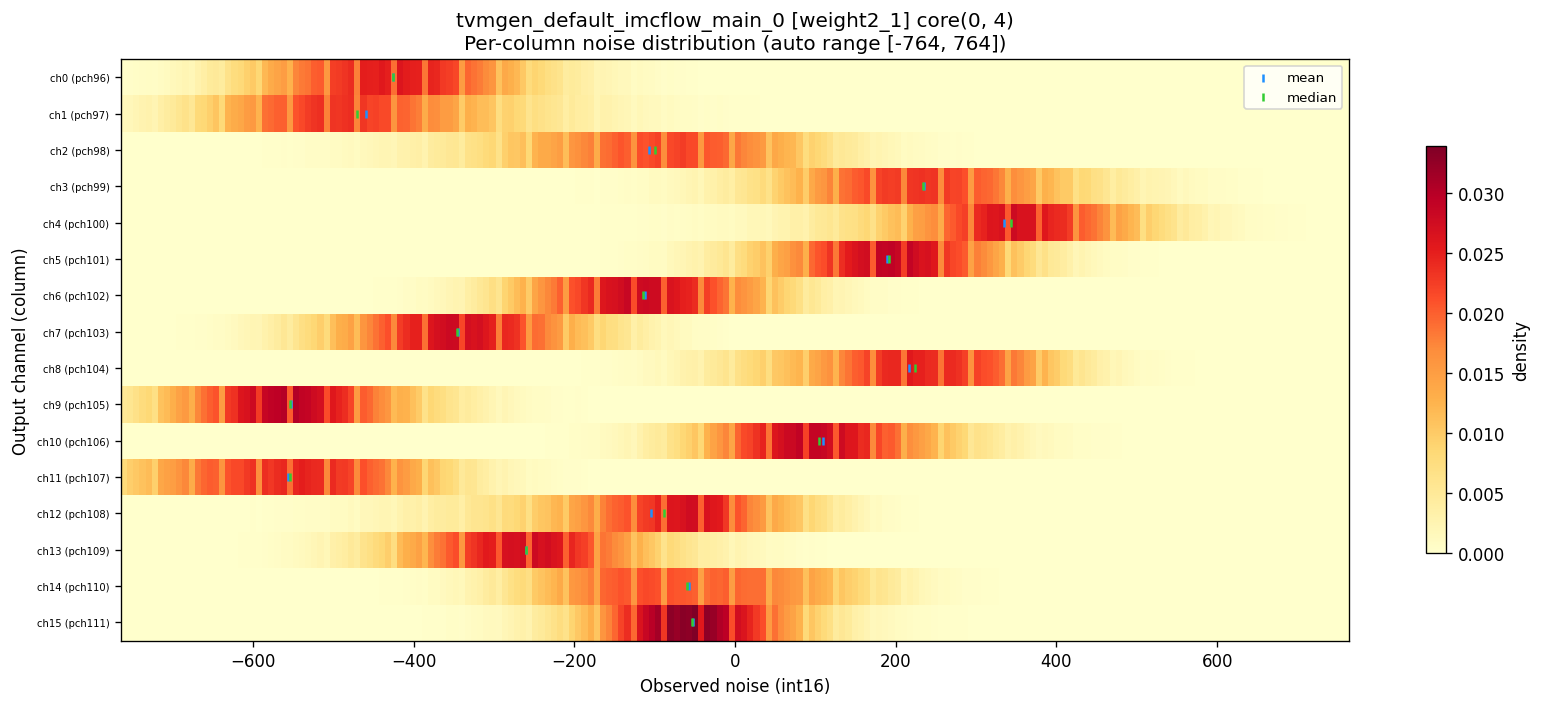

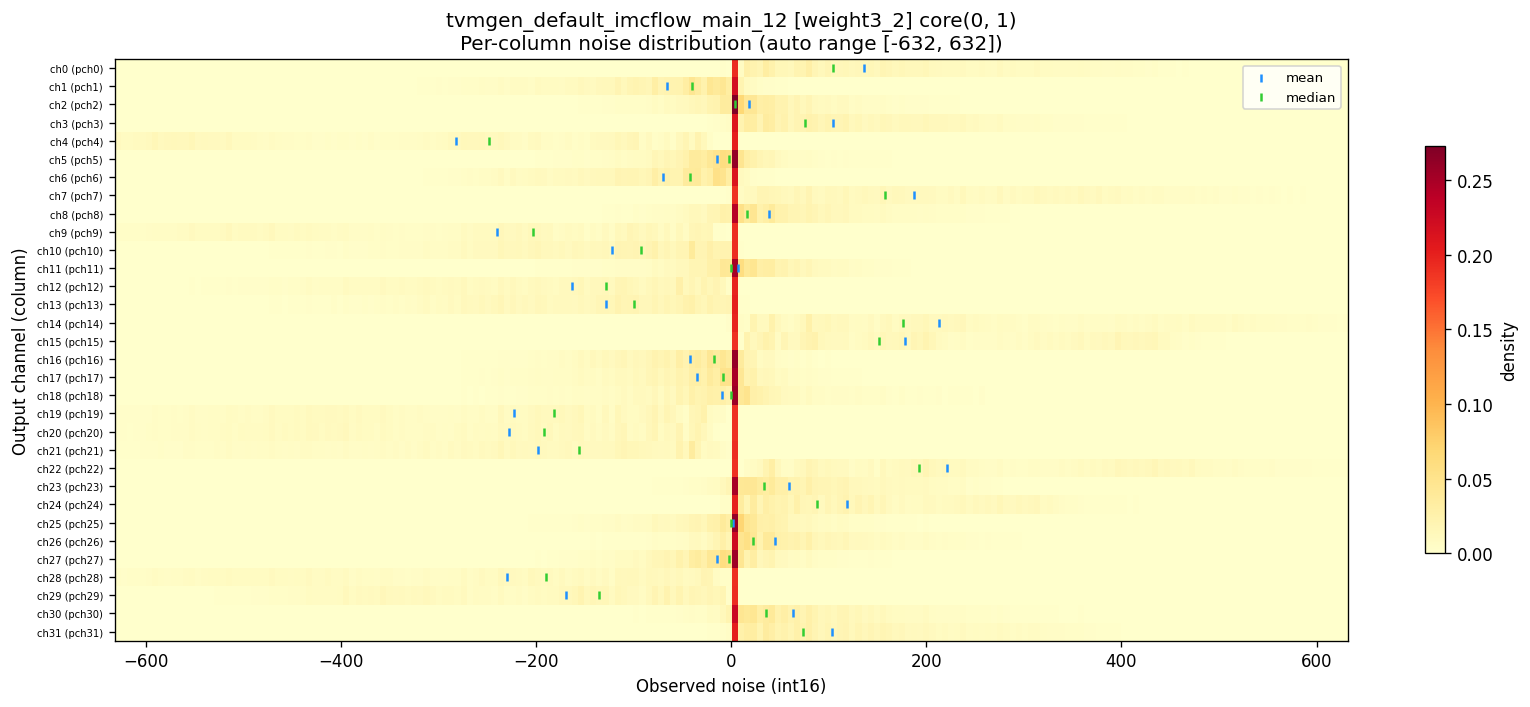

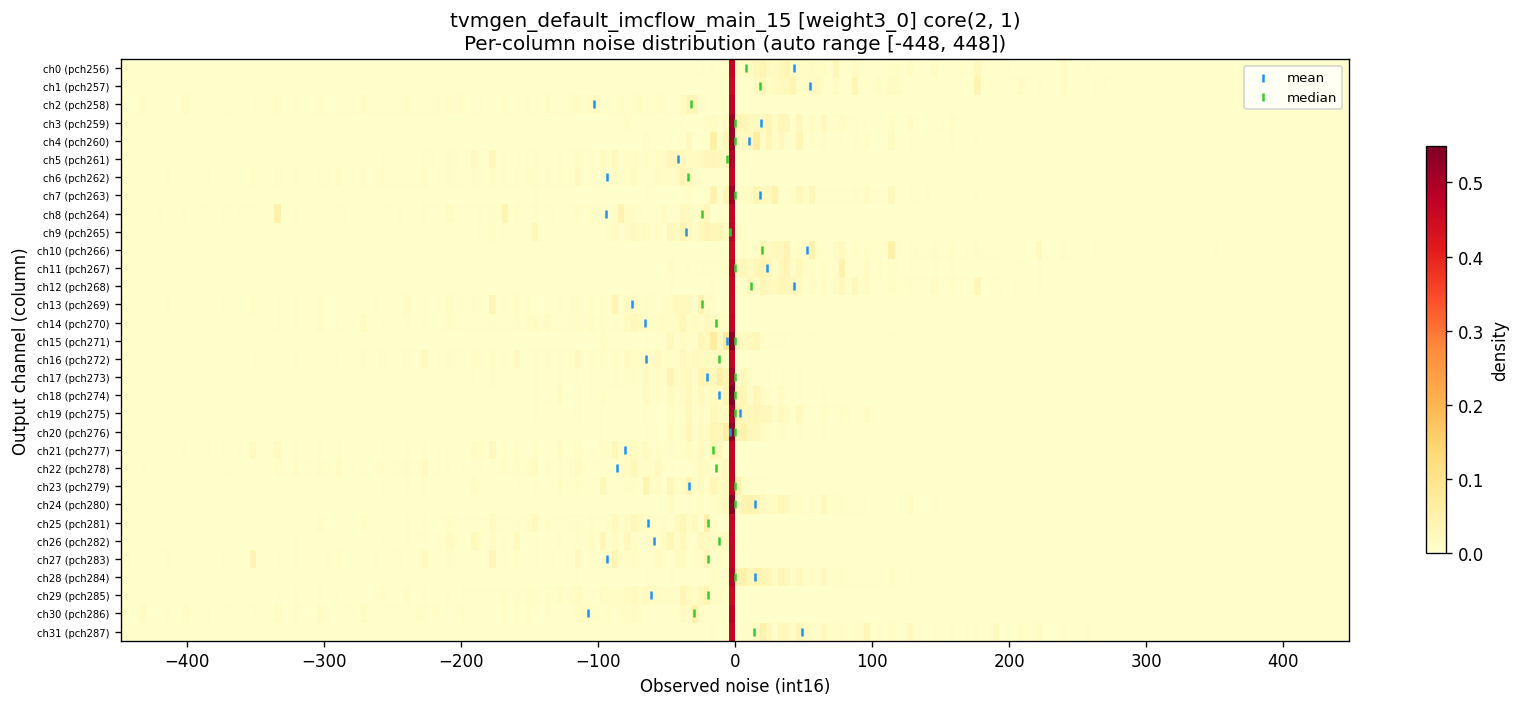

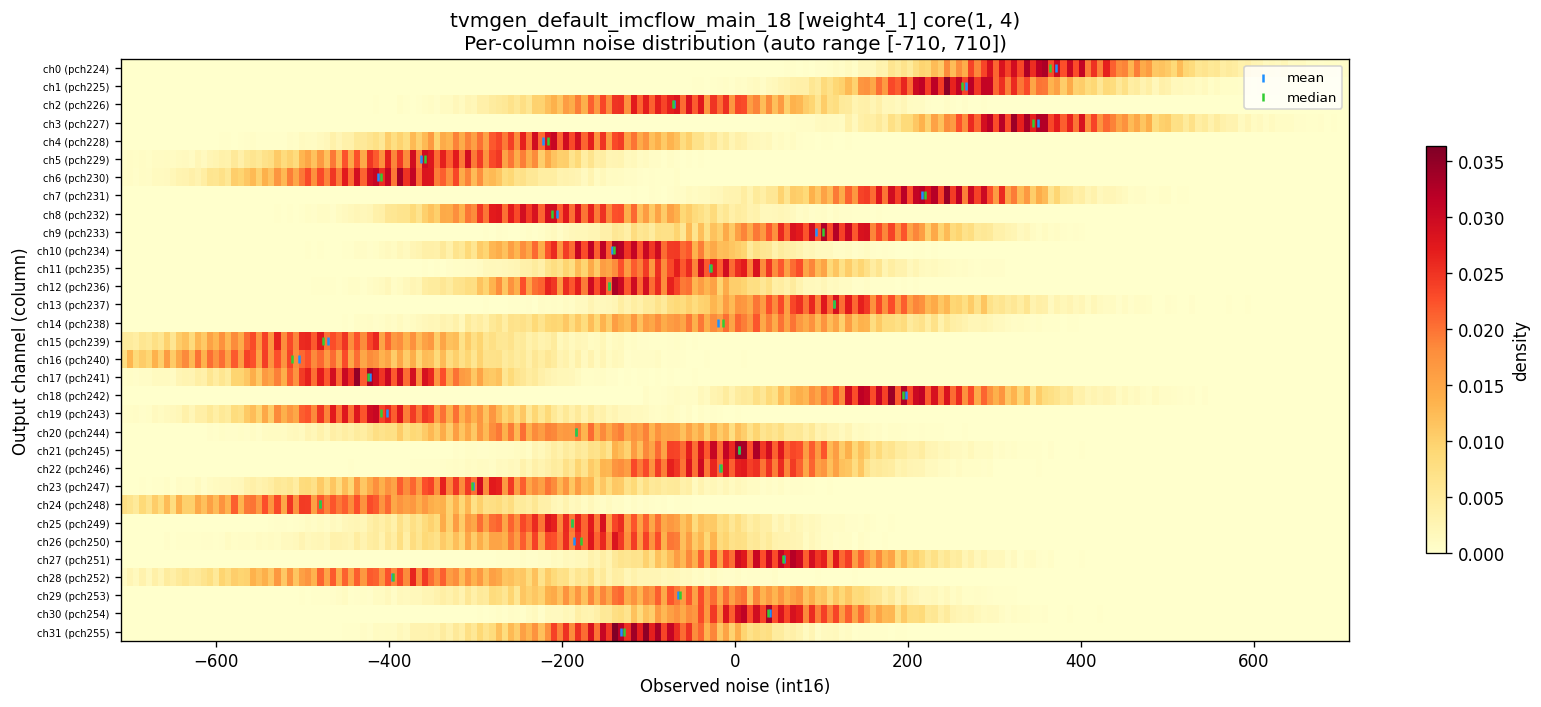

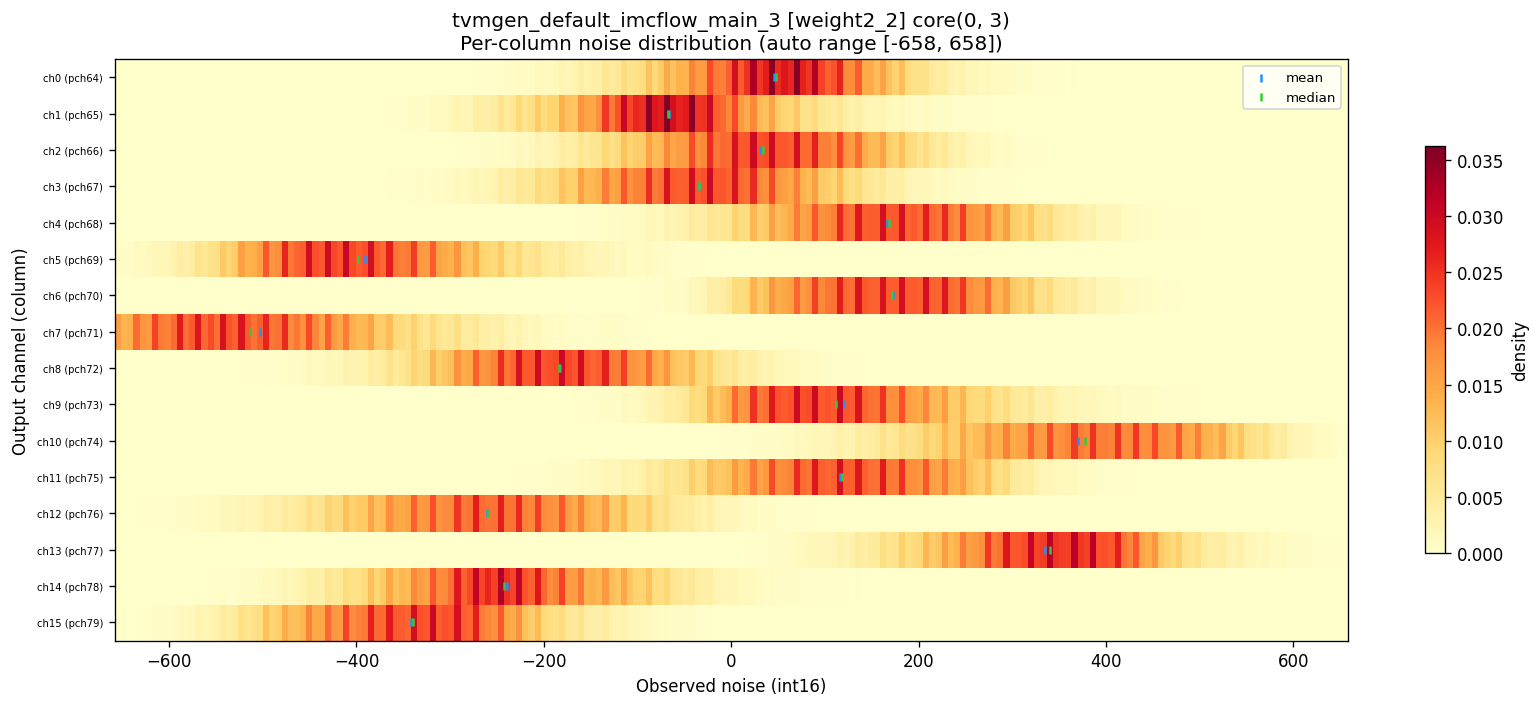

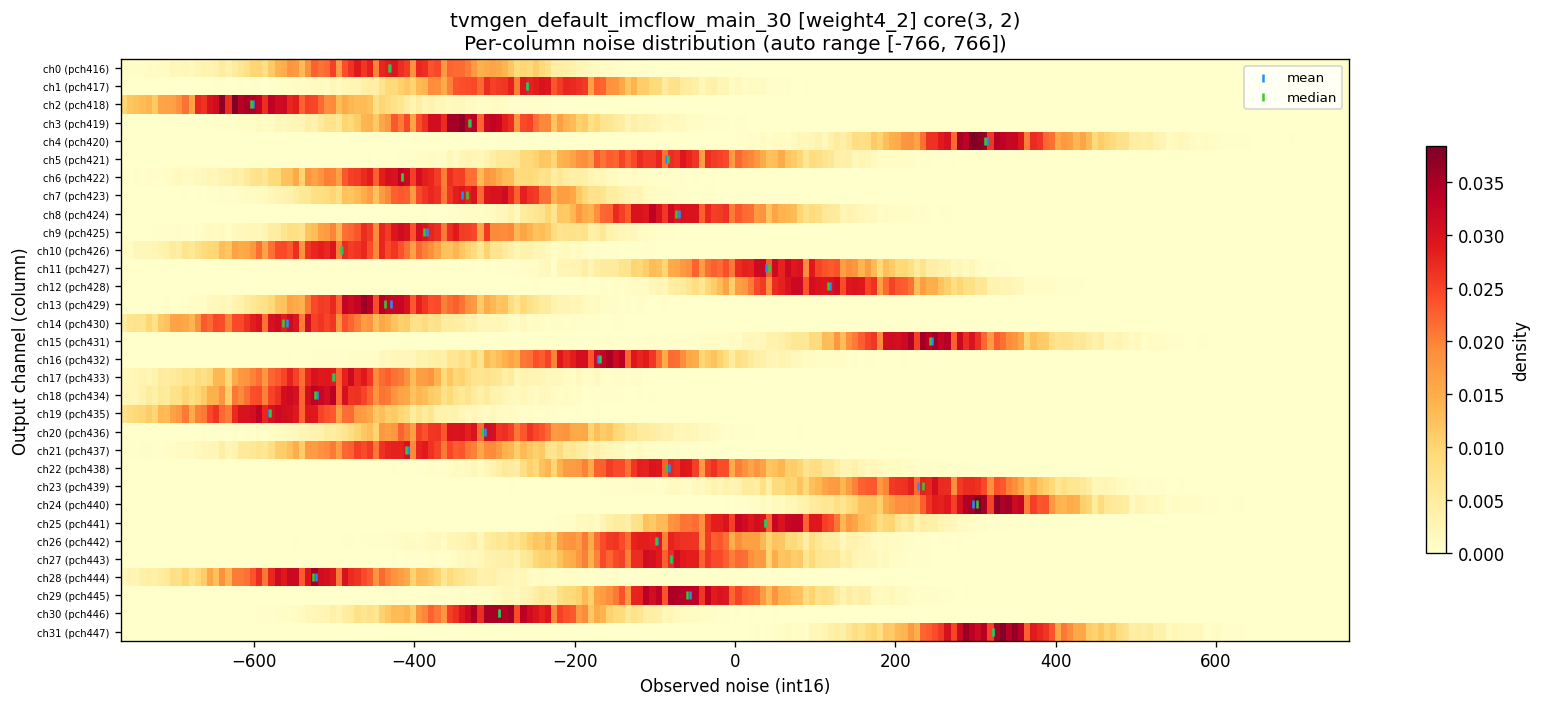

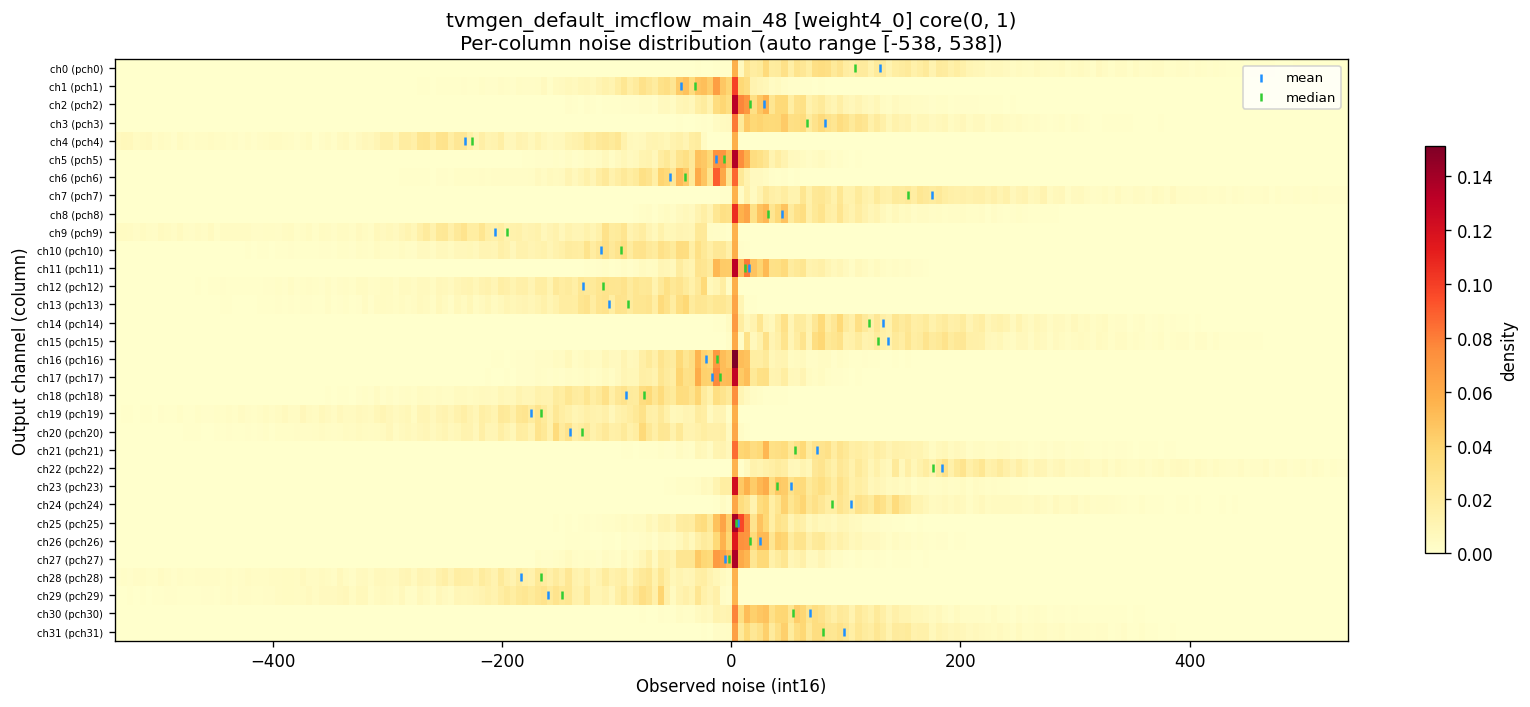

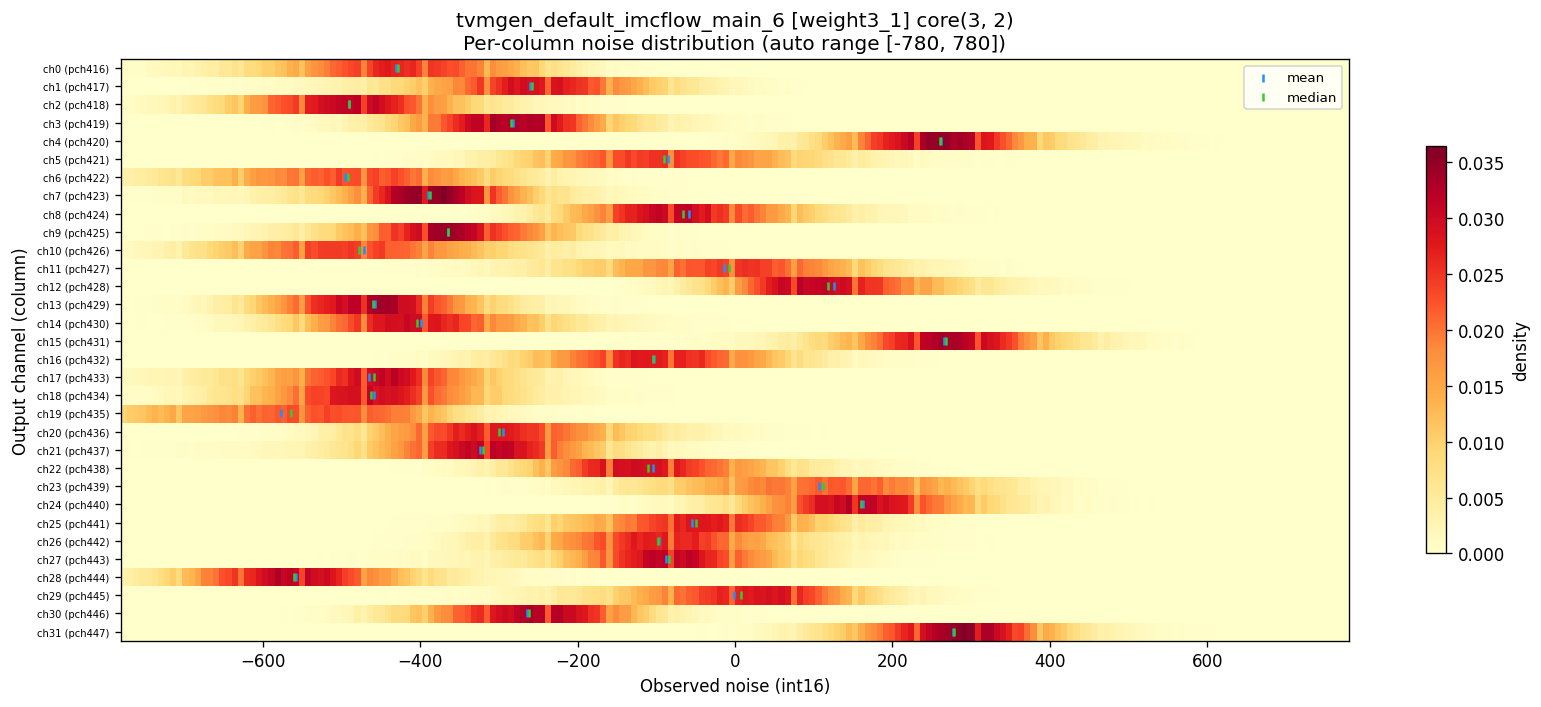

In [23]:
def plot_per_column_noise_heatmap(func, stacked, n_bins=200, figsize=(14, 6)):
    """Heatmap: y=column (pseudo_ch), x=noise_bin, value=count.
    bin_range is auto-determined from data to avoid clipping.
    Overlays per-channel mean (blue), median (green), and mode (red) markers."""
    s = stacked[func]
    obs = s['obs']           # (S, OC, OH, OW)
    n_cols = obs.shape[1]
    pseudo_chs = s['pseudo_chs']

    # Auto bin_range: cover 99.5th percentile of |noise|
    absmax = np.percentile(np.abs(obs), 99.5)
    absmax = max(absmax, 50)  # minimum range
    bin_range = (-absmax, absmax)
    bins = np.linspace(bin_range[0], bin_range[1], n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    hist_mat = np.zeros((n_cols, n_bins), dtype=np.float64)
    ch_means = np.zeros(n_cols)
    ch_medians = np.zeros(n_cols)
    ch_modes = np.zeros(n_cols)
    for oc in range(n_cols):
        vals = obs[:, oc, :, :].ravel()
        h, _ = np.histogram(vals, bins=bins)
        total = h.sum()
        if total > 0:
            hist_mat[oc] = h / total
        ch_means[oc] = vals.mean()
        ch_medians[oc] = np.median(vals)
        ch_modes[oc] = bin_centers[np.argmax(h)]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(hist_mat, aspect='auto', cmap='YlOrRd', interpolation='nearest',
                   extent=[bin_range[0], bin_range[1], n_cols - 0.5, -0.5])
    ax.set_xlabel('Observed noise (int16)')
    ax.set_ylabel('Output channel (column)')
    ax.set_title(f'{func} [{s["orig_conv"]}] core{s["core"]}\nPer-column noise distribution (auto range [{bin_range[0]:.0f}, {bin_range[1]:.0f}])')
    fig.colorbar(im, ax=ax, label='density', shrink=0.7)

    # Overlay mean / median / mode markers
    ys = np.arange(n_cols)
    ax.scatter(ch_means, ys, color='dodgerblue', s=18, marker='|', linewidths=1.5,
               zorder=5, label=f'mean')
    ax.scatter(ch_medians, ys, color='limegreen', s=18, marker='|', linewidths=1.5,
               zorder=5, label=f'median')
    ax.legend(fontsize=8, loc='upper right')

    # Annotate pseudo_ch ids on y-axis
    if n_cols <= 64:
        ax.set_yticks(range(n_cols))
        ax.set_yticklabels([f'ch{oc} (pch{pseudo_chs[oc]})' for oc in range(n_cols)], fontsize=6)
    fig.tight_layout()
    return fig, ax

# Plot for a few representative atomics (one per orig_conv)
seen_orig = set()
for f in atomic_funcs:
    orig = stacked[f]['orig_conv']
    if orig in seen_orig:
        continue
    seen_orig.add(orig)
    plot_per_column_noise_heatmap(f, stacked)
    plt.show()

## 5.1 Per-column bias comparison: Observed (chip) vs Predicted (CSV)

Compare the per-channel mean bias from actual chip measurement vs CSV noise model prediction.
This reveals how well the noise CSV captures physical column-level bias.

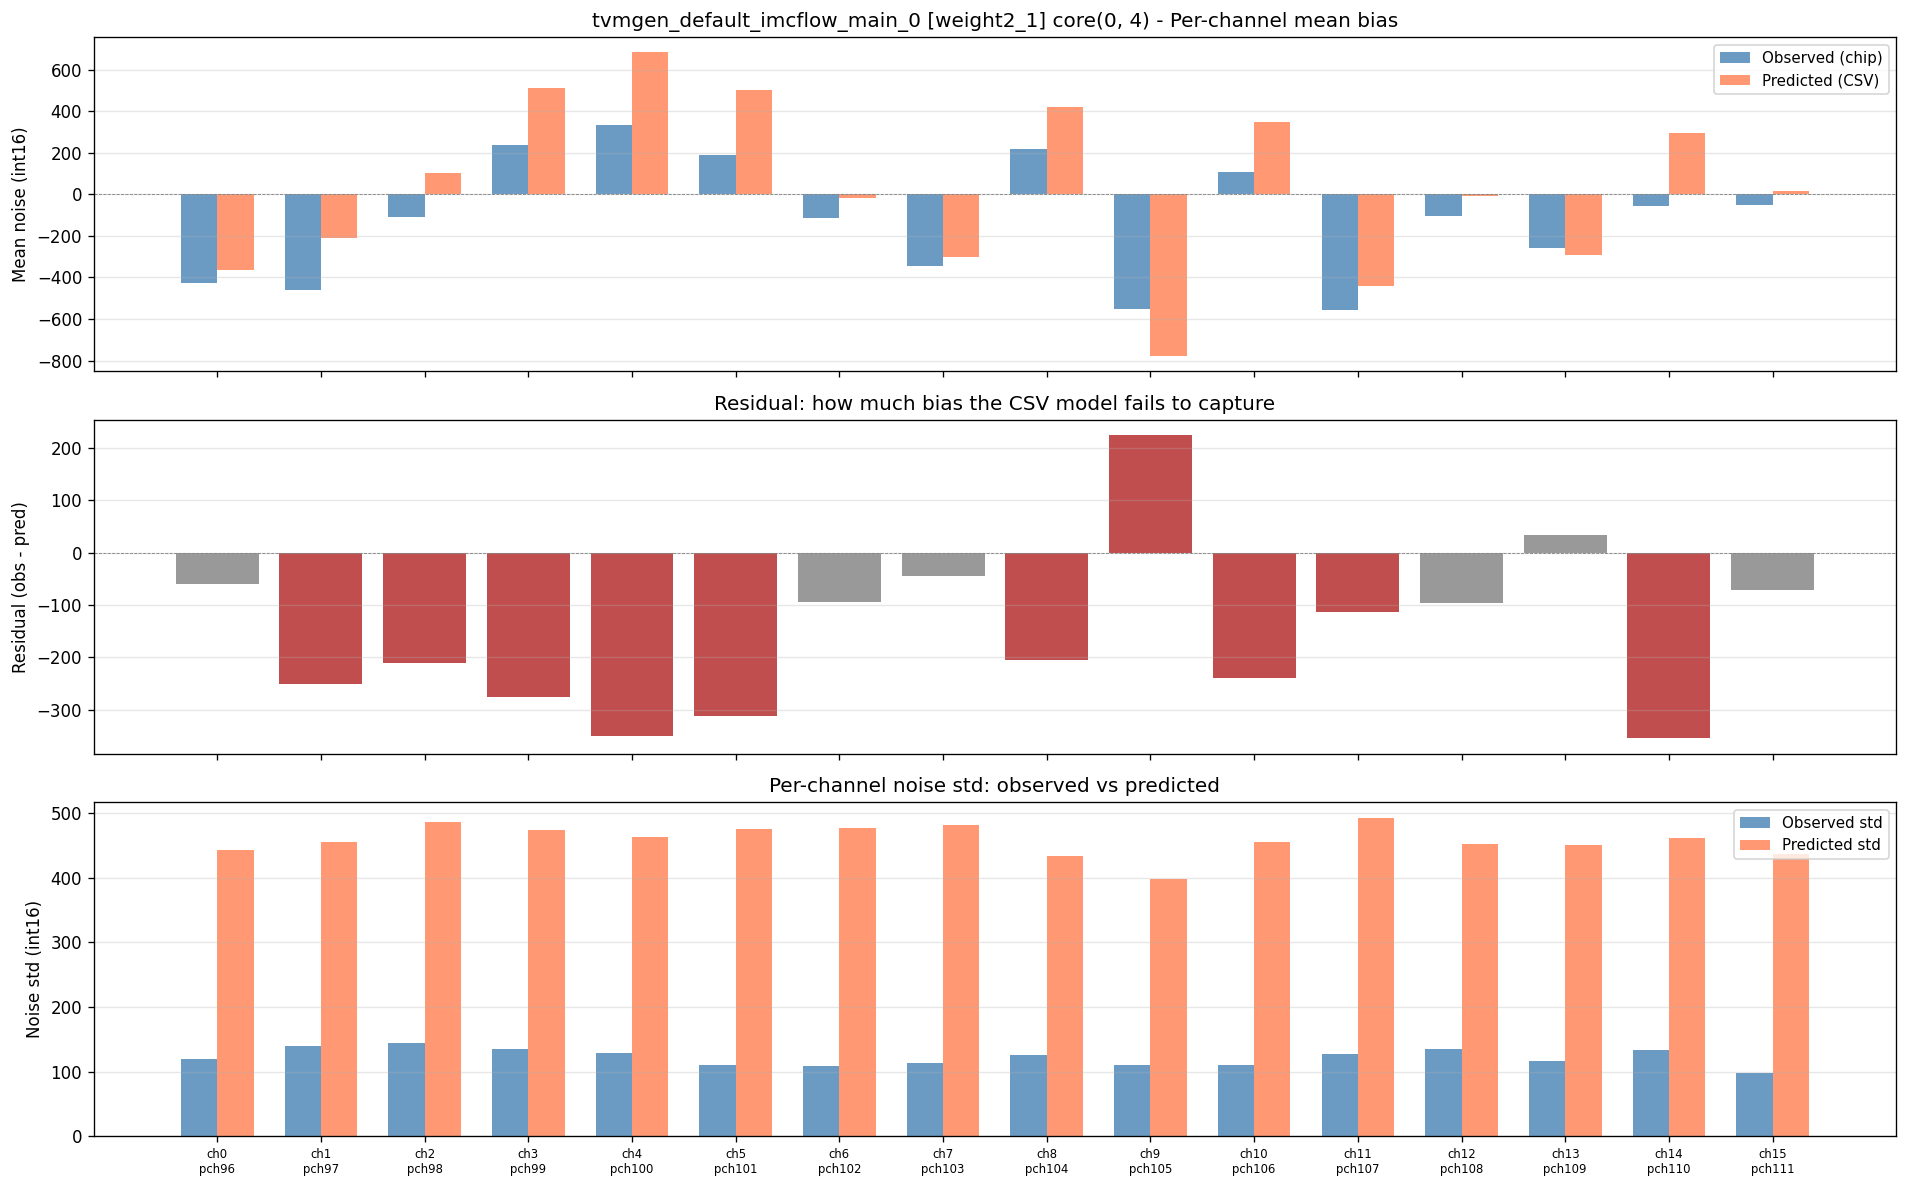

weight2_1 core(0,4):
channel  pseudo_ch  obs_mean  pred_mean  residual  obs_std  pred_std
    ch0         96    -425.3     -365.4     -59.9    119.0     442.4
    ch1         97    -459.5     -208.0    -251.5    140.0     455.4
    ch2         98    -107.4      102.8    -210.2    145.1     486.9
    ch3         99     235.6      510.5    -275.0    135.1     473.4
    ch4        100     335.0      684.3    -349.3    129.7     462.8
    ch5        101     189.3      501.2    -311.9    110.2     474.7
    ch6        102    -112.0      -18.5     -93.5    109.4     476.7
    ch7        103    -344.9     -300.4     -44.5    113.5     481.9
    ch8        104     216.8      420.8    -204.1    125.4     434.2
    ch9        105    -552.0     -776.8     224.8    110.8     397.4
   ch10        106     109.0      348.6    -239.6    111.0     455.1
   ch11        107    -556.8     -442.9    -114.0    127.2     491.9
   ch12        108    -104.8       -8.6     -96.2    135.8     452.1
   ch13      

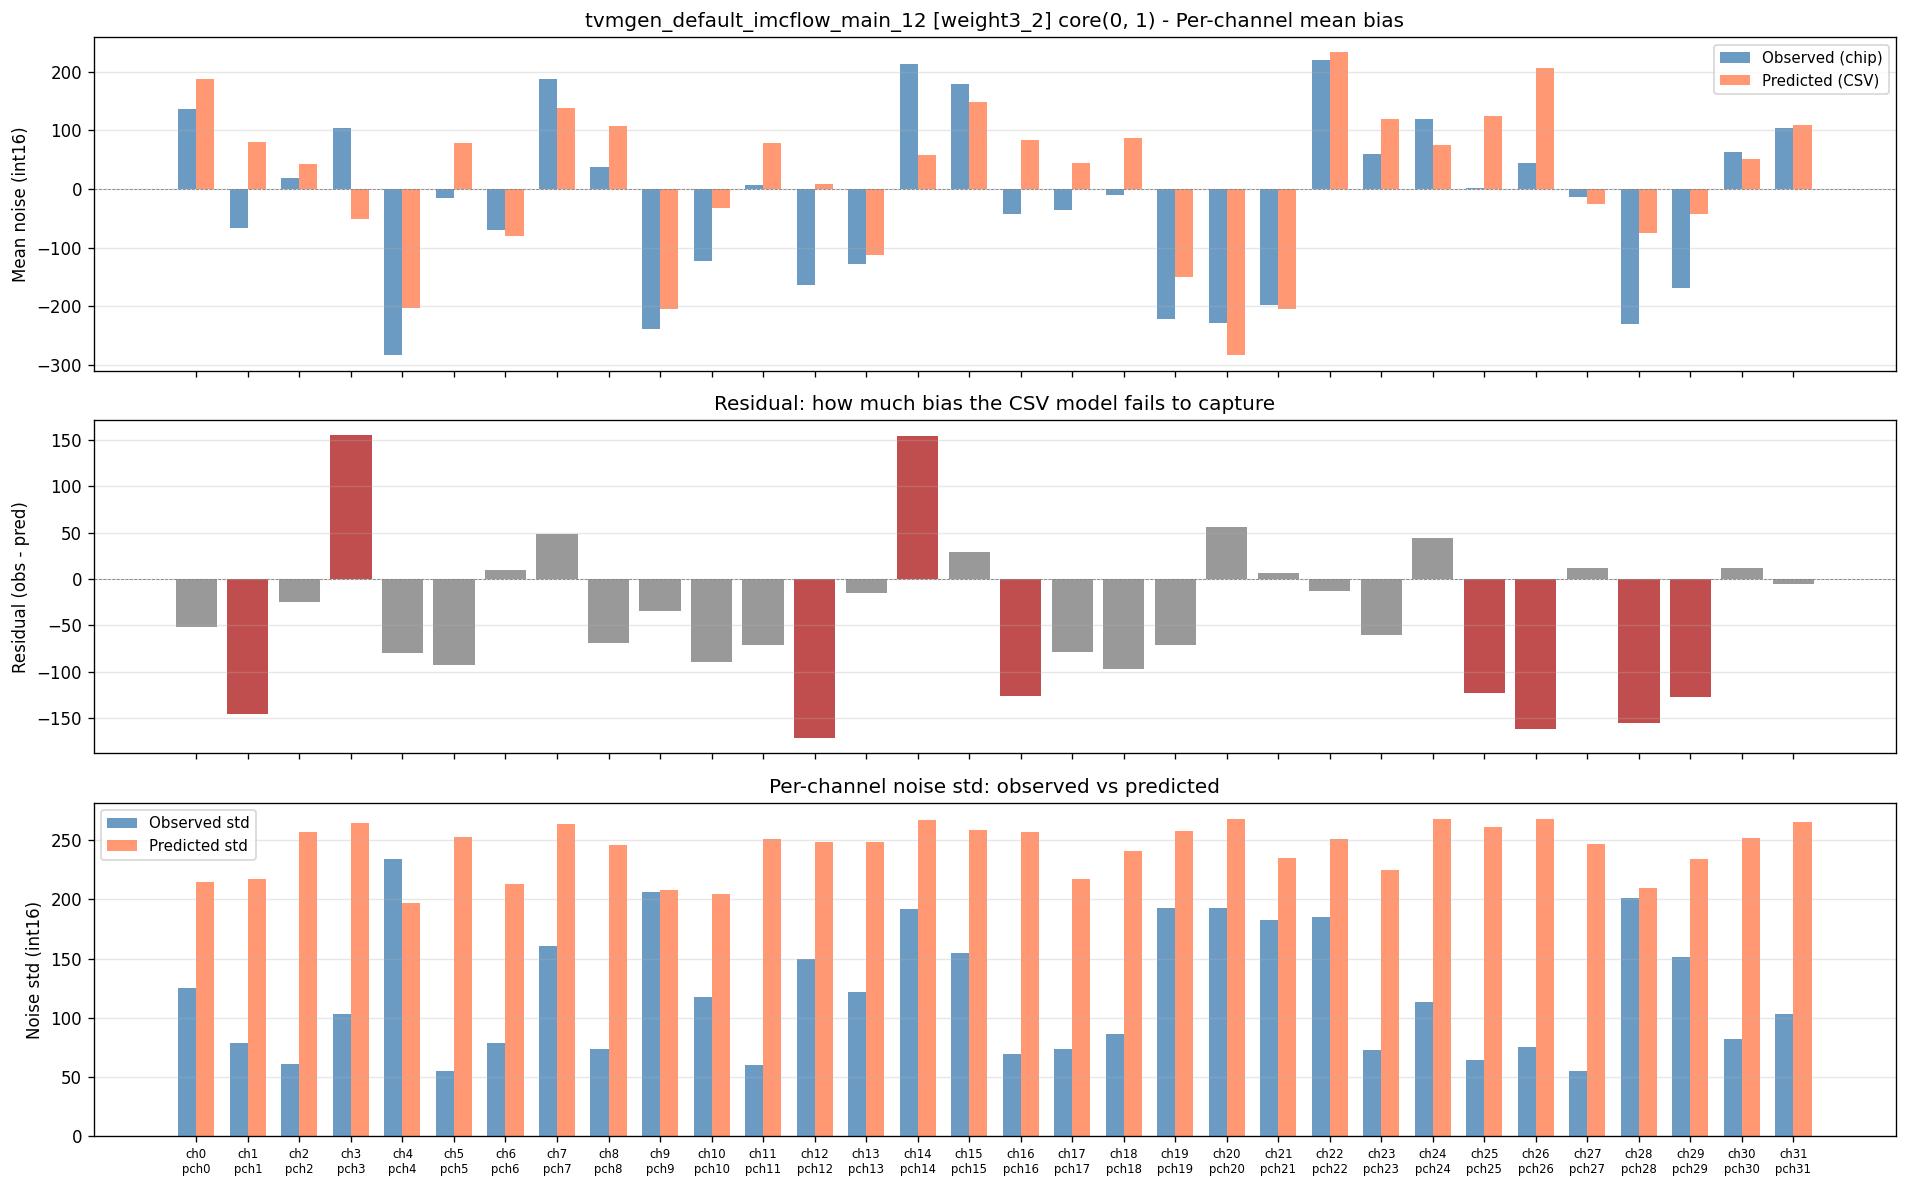


weight3_2 core(0,1):
channel  pseudo_ch  obs_mean  pred_mean  residual  obs_std  pred_std
    ch0          0     136.0      188.2     -52.2    125.1     214.8
    ch1          1     -66.0       80.0    -146.0     78.9     217.6
    ch2          2      18.7       43.3     -24.6     60.7     256.8
    ch3          3     104.3      -50.9     155.2    103.5     264.6
    ch4          4    -282.6     -202.3     -80.3    234.2     197.1
    ch5          5     -15.1       77.9     -93.0     55.3     252.3
    ch6          6     -70.3      -79.6       9.3     79.1     212.8
    ch7          7     187.1      138.3      48.8    160.7     263.7
    ch8          8      38.3      107.9     -69.6     73.3     246.2
    ch9          9    -239.7     -205.1     -34.7    206.0     207.7
   ch10         10    -122.1      -32.3     -89.8    117.6     204.7
   ch11         11       7.3       78.7     -71.5     59.9     251.1
   ch12         12    -163.1        8.8    -172.0    149.3     248.7
   ch13     

In [24]:
import pandas as pd  # re-import in case pd was shadowed

def plot_per_column_bias_comparison(func_name, stacked, figsize=(16, 10)):
    """Per-channel bar chart: observed mean bias vs CSV predicted mean bias.
    Also shows residual (obs - pred) and std comparison."""
    s = stacked[func_name]
    obs = s['obs']         # (S, OC, OH, OW)
    pred_E = s['pred_E']   # (S, OC, OH, OW)
    pred_Var = s['pred_Var']
    n_cols = obs.shape[1]
    pseudo_chs = s['pseudo_chs']

    # Per-channel statistics (mean across all samples & spatial positions)
    obs_mean = np.array([obs[:, oc].ravel().mean() for oc in range(n_cols)])
    obs_std  = np.array([obs[:, oc].ravel().std()  for oc in range(n_cols)])
    pred_mean = np.array([pred_E[:, oc].ravel().mean() for oc in range(n_cols)])
    pred_std  = np.array([np.sqrt(pred_Var[:, oc].ravel()).mean() for oc in range(n_cols)])
    residual = obs_mean - pred_mean

    x = np.arange(n_cols)
    labels = [f'ch{oc}\npch{pseudo_chs[oc]}' for oc in range(n_cols)]
    w = 0.35

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)

    # (a) Mean bias comparison
    ax = axes[0]
    ax.bar(x - w/2, obs_mean, w, label='Observed (chip)', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, pred_mean, w, label='Predicted (CSV)', color='coral', alpha=0.8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_ylabel('Mean noise (int16)')
    ax.set_title(f'{func_name} [{s["orig_conv"]}] core{s["core"]} - Per-channel mean bias')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # (b) Residual (obs - pred)
    ax = axes[1]
    colors = ['firebrick' if abs(r) > 100 else 'gray' for r in residual]
    ax.bar(x, residual, color=colors, alpha=0.8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_ylabel('Residual (obs - pred)')
    ax.set_title('Residual: how much bias the CSV model fails to capture')
    ax.grid(axis='y', alpha=0.3)

    # (c) Std comparison
    ax = axes[2]
    ax.bar(x - w/2, obs_std, w, label='Observed std', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, pred_std, w, label='Predicted std', color='coral', alpha=0.8)
    ax.set_ylabel('Noise std (int16)')
    ax.set_title('Per-channel noise std: observed vs predicted')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7, rotation=0)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    fig.tight_layout()
    return fig, axes, pd.DataFrame({
        'channel': [f'ch{oc}' for oc in range(n_cols)],
        'pseudo_ch': pseudo_chs,
        'obs_mean': obs_mean, 'pred_mean': pred_mean,
        'residual': residual,
        'obs_std': obs_std, 'pred_std': pred_std,
    })


# === weight2_1 core(0,4) ===
fig1, ax1, df_w21 = plot_per_column_bias_comparison(
    'tvmgen_default_imcflow_main_0', stacked)
plt.show()
print("weight2_1 core(0,4):")
print(df_w21.to_string(index=False, float_format='{:.1f}'.format))

print(f"\n  Obs mean bias range:  [{df_w21['obs_mean'].min():.0f}, {df_w21['obs_mean'].max():.0f}]")
print(f"  Pred mean bias range: [{df_w21['pred_mean'].min():.0f}, {df_w21['pred_mean'].max():.0f}]")
print(f"  Residual |mean|:      {df_w21['residual'].abs().mean():.0f}")

# === weight3_2 core(0,1) ===
# imcflow_main_12 is weight3_2 core(0,1)
fig2, ax2, df_w32 = plot_per_column_bias_comparison(
    'tvmgen_default_imcflow_main_12', stacked)
plt.show()
print("\nweight3_2 core(0,1):")
print(df_w32.to_string(index=False, float_format='{:.1f}'.format))

print(f"\n  Obs mean bias range:  [{df_w32['obs_mean'].min():.0f}, {df_w32['obs_mean'].max():.0f}]")
print(f"  Pred mean bias range: [{df_w32['pred_mean'].min():.0f}, {df_w32['pred_mean'].max():.0f}]")
print(f"  Residual |mean|:      {df_w32['residual'].abs().mean():.0f}")

## 5.2 Per-channel: Observed vs Predicted noise conditioned on predicted value

For channels where residual is large, the question is: is the CSV wrong everywhere,
or only at certain predicted-noise levels (which correspond to certain ref/input patterns)?

**Approach**: For each output element we have `pred_E` and `obs` (both at int16 level).
Bin by `pred_E` value, then plot `mean(obs)` vs `pred_E` bin. If CSV is perfect,
this should be a diagonal. Deviations show *which predicted noise regions* are miscalibrated.

weight2_1 core(0,4)


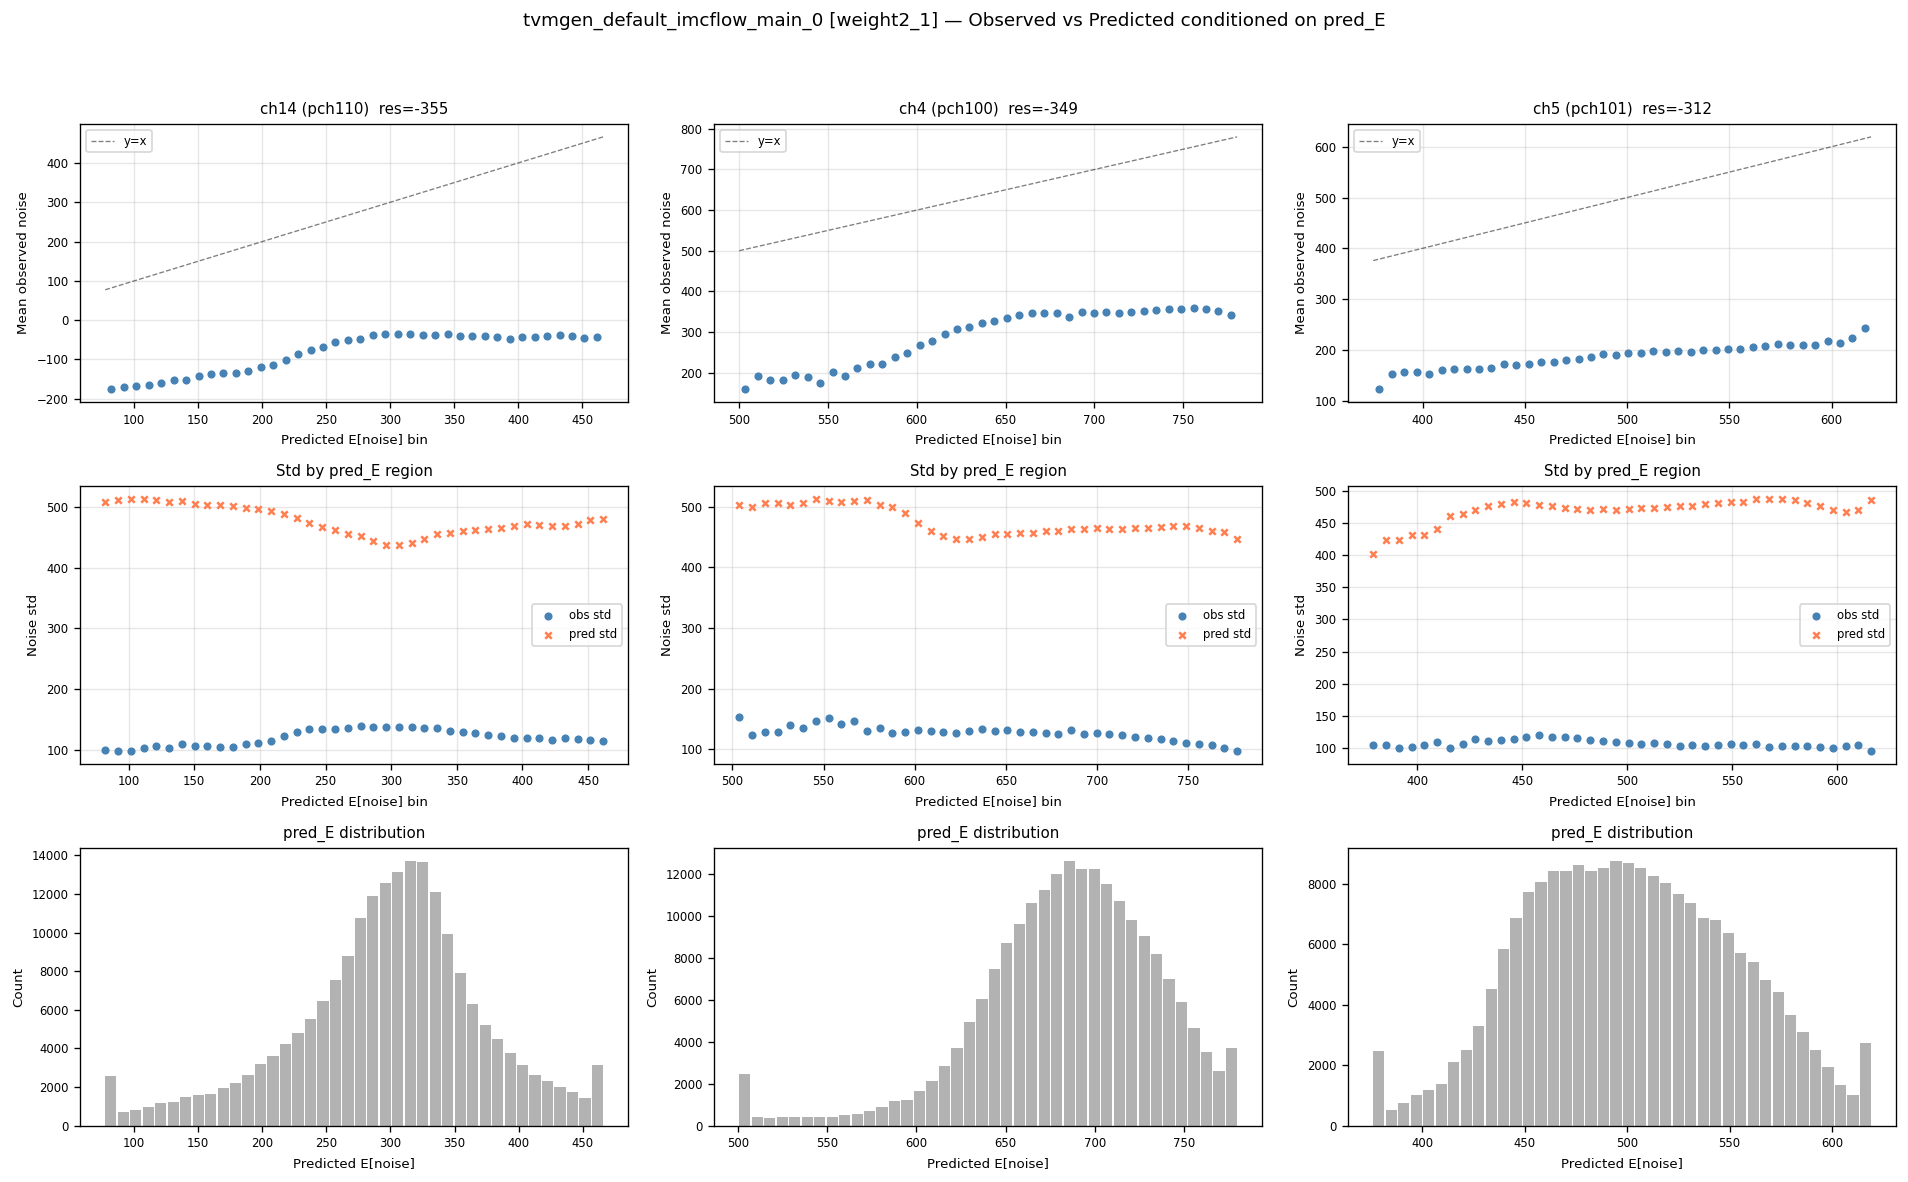


weight3_2 core(0,1)


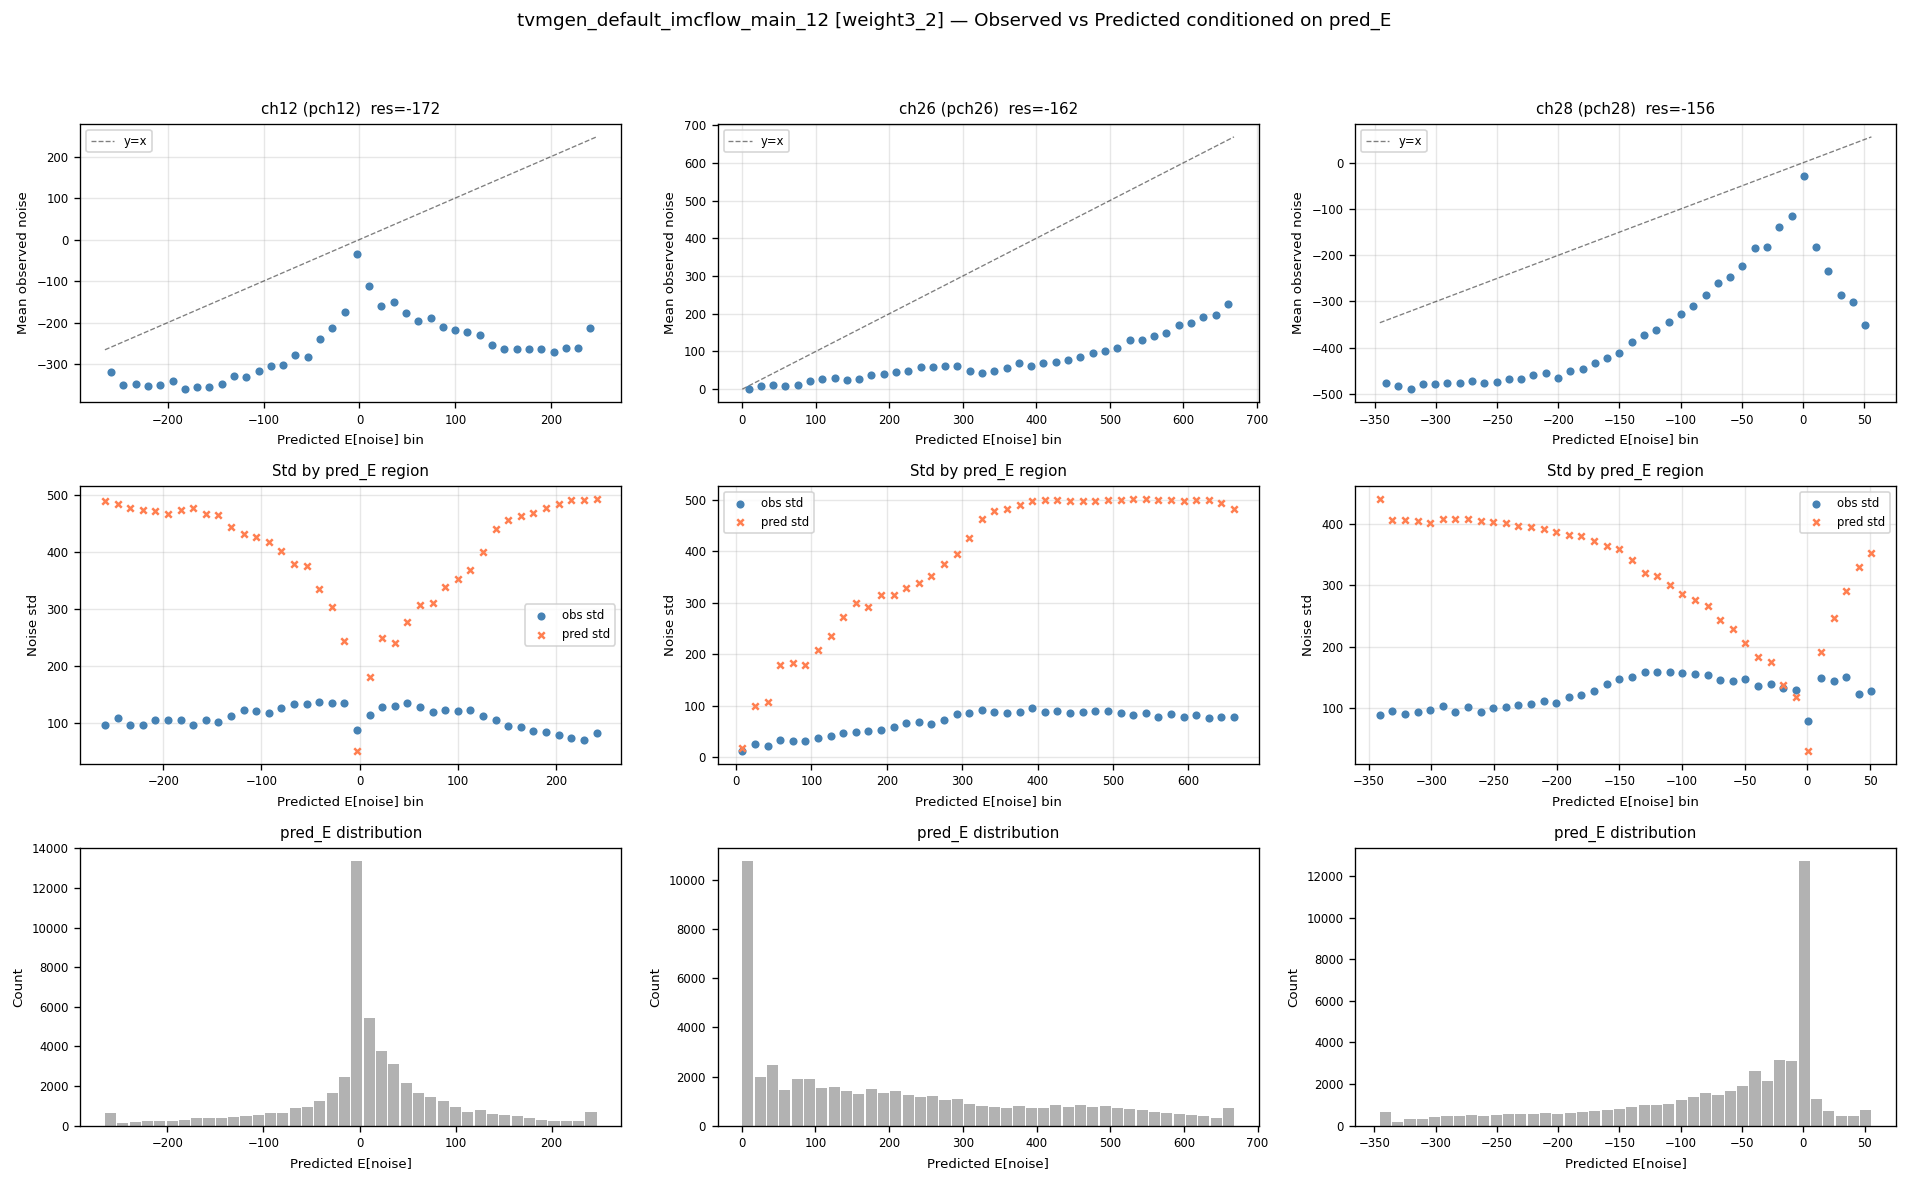

In [30]:
def plot_obs_vs_pred_conditioned(func_name, stacked, target_ocs=None,
                                  n_bins=40, figsize=(16, 5)):
    """Per-channel: bin output elements by pred_E, show mean(obs) and std(obs) per bin.
    
    Top row: mean(obs) vs pred_E bin (diagonal = perfect).
    Bottom row: std(obs) vs pred_E bin, compared to predicted std.
    Also shows the pred_E histogram to see which regions have data.
    """
    s = stacked[func_name]
    obs = s['obs']       # (S, OC, OH, OW)
    pred_E = s['pred_E']
    pred_Var = s['pred_Var']
    pseudo_chs = s['pseudo_chs']
    OC = obs.shape[1]
    
    if target_ocs is None:
        obs_mean = np.array([obs[:, oc].mean() for oc in range(OC)])
        pred_mean = np.array([pred_E[:, oc].mean() for oc in range(OC)])
        residuals = np.abs(obs_mean - pred_mean)
        target_ocs = list(np.argsort(residuals)[-3:][::-1])
    
    n_ch = len(target_ocs)
    fig, axes = plt.subplots(3, n_ch, figsize=(figsize[0], figsize[1] * n_ch / 3 * 2),
                             squeeze=False)
    
    for col, oc in enumerate(target_ocs):
        pch = pseudo_chs[oc]
        o = obs[:, oc].ravel().astype(np.float64)
        p = pred_E[:, oc].ravel()
        pv = pred_Var[:, oc].ravel()
        
        # Bin by pred_E
        p_min, p_max = np.percentile(p, [1, 99])
        bin_edges = np.linspace(p_min, p_max, n_bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_idx = np.digitize(p, bin_edges) - 1  # 0..n_bins-1
        bin_idx = np.clip(bin_idx, 0, n_bins - 1)
        
        obs_bin_mean = np.full(n_bins, np.nan)
        obs_bin_std = np.full(n_bins, np.nan)
        pred_bin_std = np.full(n_bins, np.nan)
        bin_count = np.zeros(n_bins)
        
        for b in range(n_bins):
            mask = bin_idx == b
            cnt = mask.sum()
            bin_count[b] = cnt
            if cnt >= 20:
                obs_bin_mean[b] = o[mask].mean()
                obs_bin_std[b] = o[mask].std()
                pred_bin_std[b] = np.sqrt(pv[mask]).mean()
        
        obs_total_mean = o.mean()
        pred_total_mean = p.mean()
        residual = obs_total_mean - pred_total_mean
        
        # (a) Mean: obs vs pred_E
        ax = axes[0, col]
        valid = ~np.isnan(obs_bin_mean)
        ax.scatter(bin_centers[valid], obs_bin_mean[valid], s=15, color='steelblue', zorder=5)
        ax.plot([p_min, p_max], [p_min, p_max], 'k--', linewidth=0.8, alpha=0.5, label='y=x')
        ax.set_xlabel('Predicted E[noise] bin', fontsize=8)
        ax.set_ylabel('Mean observed noise', fontsize=8)
        ax.set_title(f'ch{oc} (pch{pch})  res={residual:.0f}', fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)
        
        # (b) Std comparison
        ax = axes[1, col]
        ax.scatter(bin_centers[valid], obs_bin_std[valid], s=15, color='steelblue',
                   label='obs std', zorder=5)
        ax.scatter(bin_centers[valid], pred_bin_std[valid], s=15, color='coral',
                   label='pred std', zorder=5, marker='x')
        ax.set_xlabel('Predicted E[noise] bin', fontsize=8)
        ax.set_ylabel('Noise std', fontsize=8)
        ax.set_title(f'Std by pred_E region', fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)
        
        # (c) Histogram of pred_E values (how many elements in each bin)
        ax = axes[2, col]
        ax.bar(bin_centers, bin_count, width=(bin_edges[1]-bin_edges[0])*0.9,
               color='gray', alpha=0.6)
        ax.set_xlabel('Predicted E[noise]', fontsize=8)
        ax.set_ylabel('Count', fontsize=8)
        ax.set_title('pred_E distribution', fontsize=9)
        ax.tick_params(labelsize=7)
    
    fig.suptitle(
        f'{func_name} [{s["orig_conv"]}] — Observed vs Predicted conditioned on pred_E',
        fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig, axes


# === weight2_1 core(0,4) — top 3 residual channels ===
print("weight2_1 core(0,4)")
fig1, _ = plot_obs_vs_pred_conditioned('tvmgen_default_imcflow_main_0', stacked)
plt.show()

# === weight3_2 core(0,1) — top 3 residual channels ===
print("\nweight3_2 core(0,1)")
fig2, _ = plot_obs_vs_pred_conditioned('tvmgen_default_imcflow_main_12', stacked)
plt.show()

### 6.4 Aggregated clean output vs observed noise

- **Left**: 2D heatmap — x = clean_ref (noise-free int16 psum), y = obs noise, color = density
- **Right**: clean_ref distribution (histogram)

This shows how noise depends on the *actual output value* (not the CSV prediction).

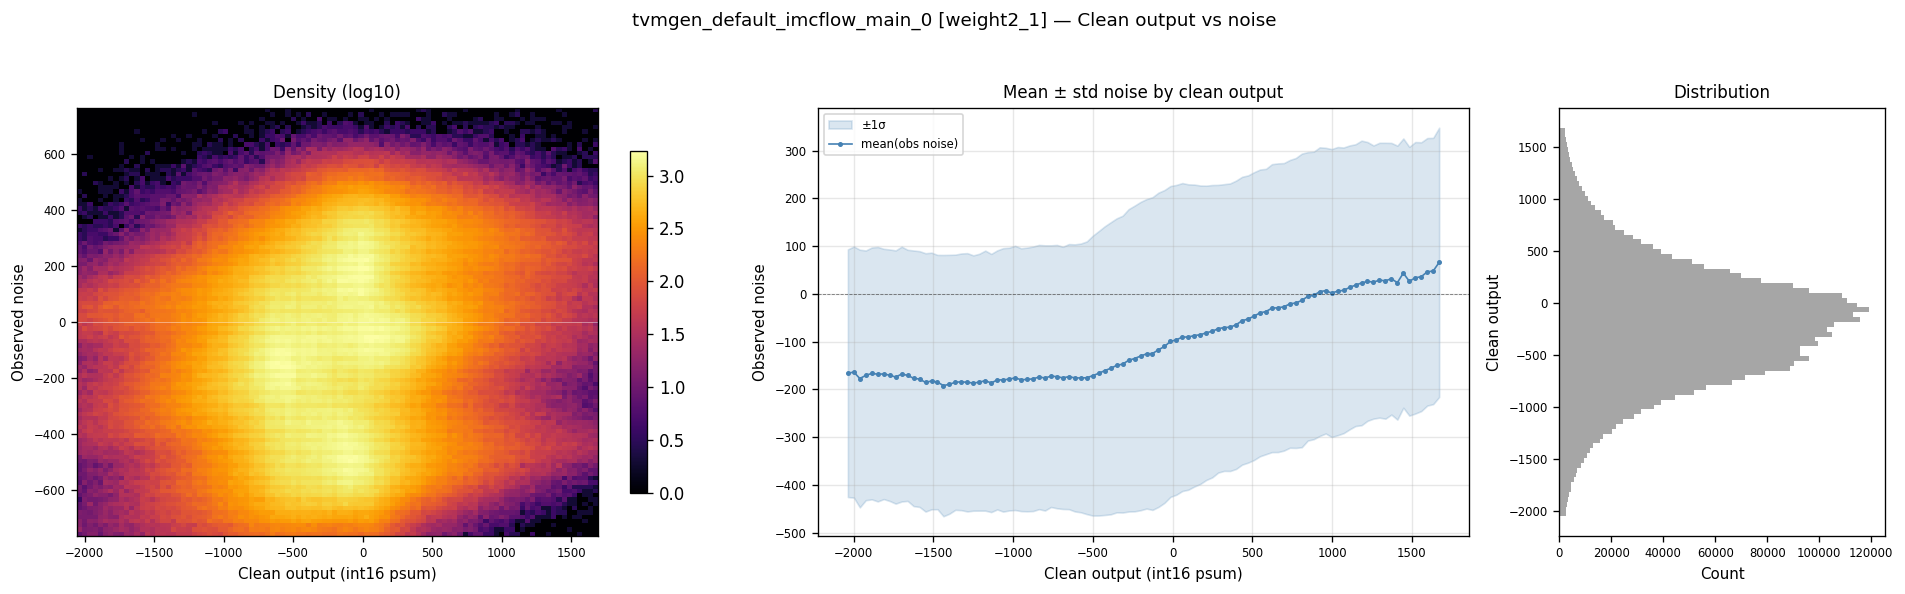

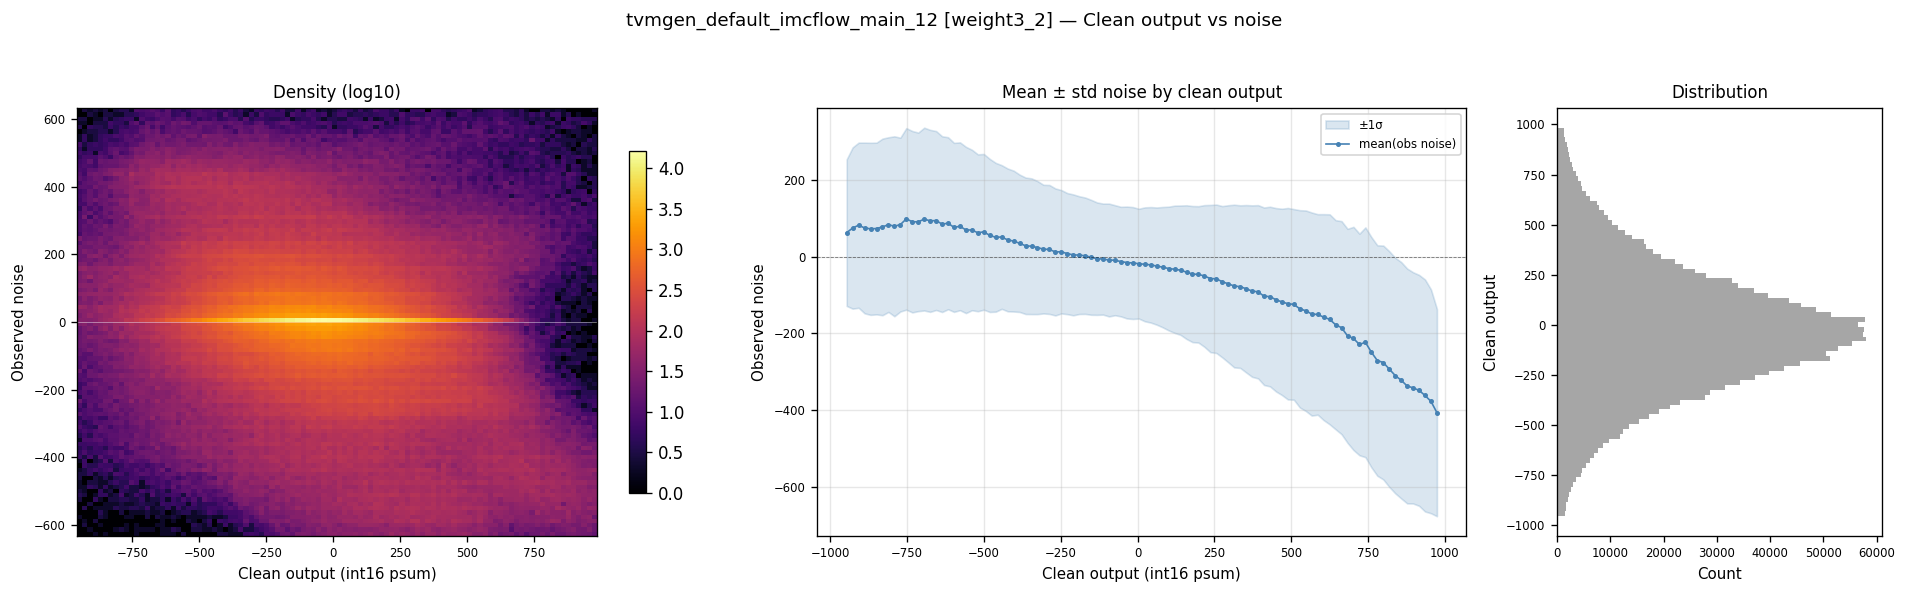

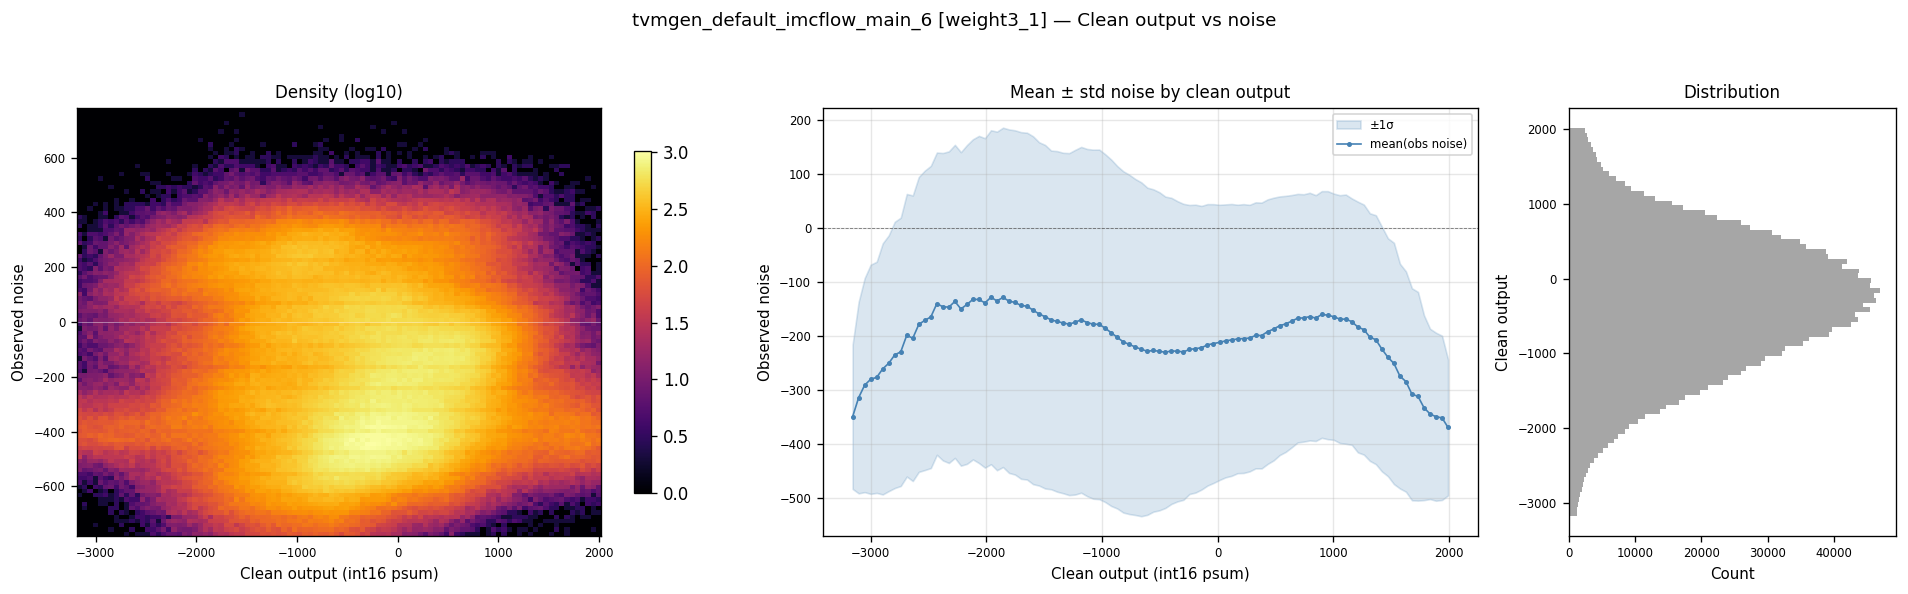

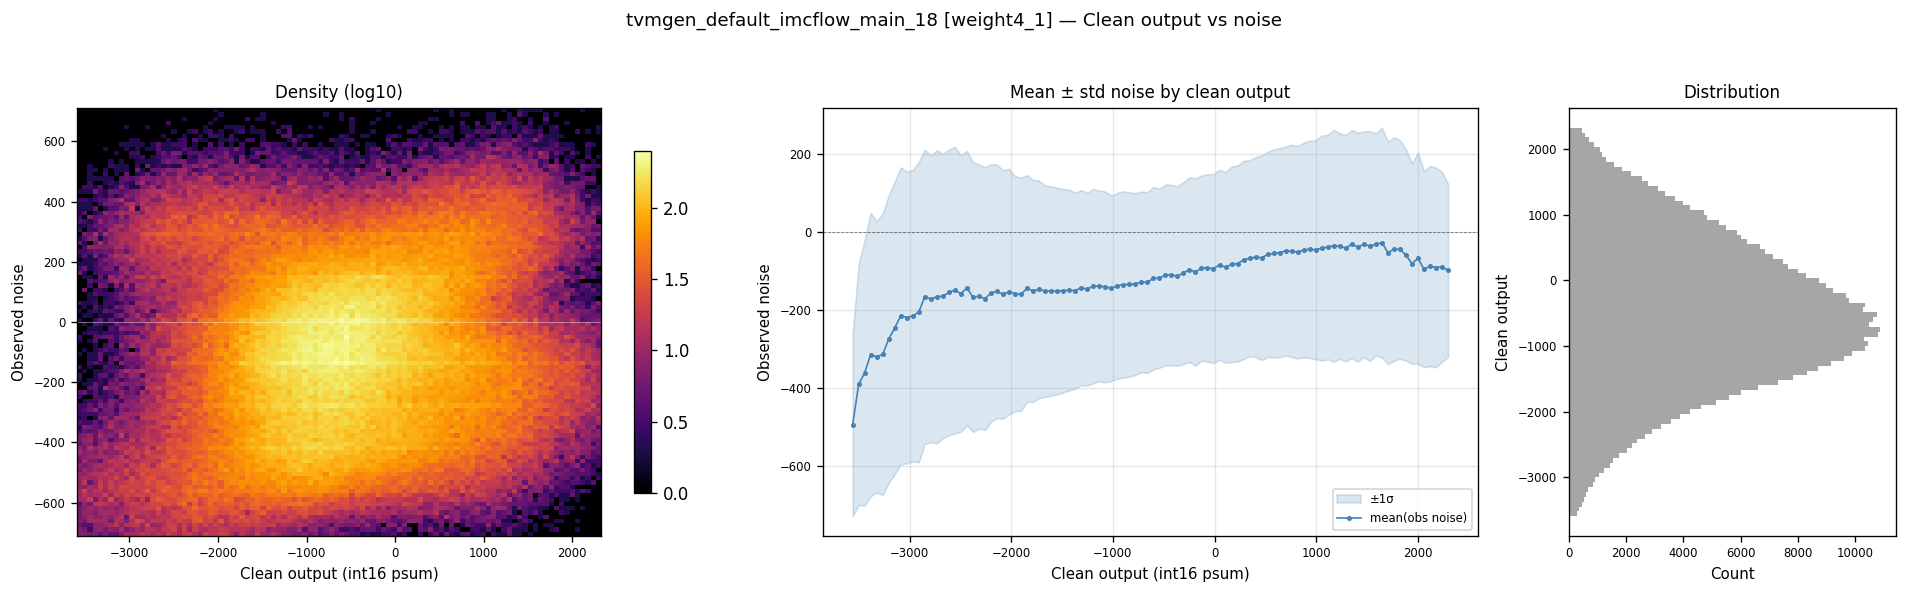

In [33]:
def plot_clean_vs_noise(func_name, stacked, n_xbins=100, n_ybins=100, figsize=(16, 5)):
    """2D heatmap: x=clean_ref (aggregated psum), y=obs noise, per pseudo_ch group."""
    s = stacked[func_name]
    clean = s['clean_ref']  # (S, OC, OH, OW) int32
    obs = s['obs']          # (S, OC, OH, OW) int32
    pseudo_chs = s['pseudo_chs']
    OC = clean.shape[1]

    # Flatten all elements
    clean_flat = clean.ravel().astype(np.float64)
    obs_flat = obs.ravel().astype(np.float64)

    # Auto range
    cx1, cx99 = np.percentile(clean_flat, [0.5, 99.5])
    oy1, oy99 = np.percentile(np.abs(obs_flat), [0, 99.5])

    fig, axes = plt.subplots(1, 3, figsize=figsize,
                             gridspec_kw={'width_ratios': [2, 2, 1]})

    # (a) 2D density heatmap: clean_ref vs obs noise
    ax = axes[0]
    h, xedges, yedges = np.histogram2d(
        clean_flat, obs_flat,
        bins=[n_xbins, n_ybins],
        range=[[cx1, cx99], [-oy99, oy99]])
    # Log-scale density
    h_log = np.log10(h.T + 1)
    im = ax.imshow(h_log, aspect='auto', origin='lower', cmap='inferno',
                   extent=[cx1, cx99, -oy99, oy99])
    ax.set_xlabel('Clean output (int16 psum)', fontsize=9)
    ax.set_ylabel('Observed noise', fontsize=9)
    ax.set_title('Density (log10)', fontsize=10)
    ax.axhline(0, color='white', linewidth=0.5, alpha=0.5)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.tick_params(labelsize=7)

    # (b) Mean noise per clean_ref bin (calibration-style)
    ax = axes[1]
    bin_edges_x = np.linspace(cx1, cx99, n_xbins + 1)
    bin_centers_x = (bin_edges_x[:-1] + bin_edges_x[1:]) / 2
    bin_idx = np.digitize(clean_flat, bin_edges_x) - 1
    bin_idx = np.clip(bin_idx, 0, n_xbins - 1)

    mean_noise = np.full(n_xbins, np.nan)
    std_noise = np.full(n_xbins, np.nan)
    bin_count = np.zeros(n_xbins)
    for b in range(n_xbins):
        mask = bin_idx == b
        cnt = mask.sum()
        bin_count[b] = cnt
        if cnt >= 50:
            mean_noise[b] = obs_flat[mask].mean()
            std_noise[b] = obs_flat[mask].std()

    valid = ~np.isnan(mean_noise)
    ax.fill_between(bin_centers_x[valid],
                    mean_noise[valid] - std_noise[valid],
                    mean_noise[valid] + std_noise[valid],
                    alpha=0.2, color='steelblue', label='±1σ')
    ax.plot(bin_centers_x[valid], mean_noise[valid], 'o-', markersize=2,
            color='steelblue', linewidth=1, label='mean(obs noise)')
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.set_xlabel('Clean output (int16 psum)', fontsize=9)
    ax.set_ylabel('Observed noise', fontsize=9)
    ax.set_title('Mean ± std noise by clean output', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

    # (c) Clean output distribution
    ax = axes[2]
    ax.hist(clean_flat, bins=80, range=(cx1, cx99), color='gray', alpha=0.7,
            orientation='horizontal')
    ax.set_xlabel('Count', fontsize=9)
    ax.set_ylabel('Clean output', fontsize=9)
    ax.set_title('Distribution', fontsize=10)
    ax.tick_params(labelsize=7)

    fig.suptitle(f'{func_name} [{s["orig_conv"]}] — Clean output vs noise', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

# Plot for key atomics
for func_name in ['tvmgen_default_imcflow_main_0',   # weight2_1
                  'tvmgen_default_imcflow_main_12',  # weight3_2
                  'tvmgen_default_imcflow_main_6',   # weight3_1
                  'tvmgen_default_imcflow_main_18']:  # weight4_1
    if func_name in stacked:
        plot_clean_vs_noise(func_name, stacked)
        plt.show()

### 6.5 Aggregated noise table heatmap

From `aggregated_noise_table.npz`: P(noise | pseudo_ch, clean_ref).

Per pseudo_ch heatmap: x = observed noise (diff), y = int16 psum reference (clean_ref bin), color = probability density.

Noise table: (512, 200, 200)
  Ref range: [-5520, 3908]
  Noise range: [-1106, 1106]
Noisiest pseudo_chs: [57, 435, 153, 105]
Cleanest pseudo_chs: [275, 276, 260, 263]


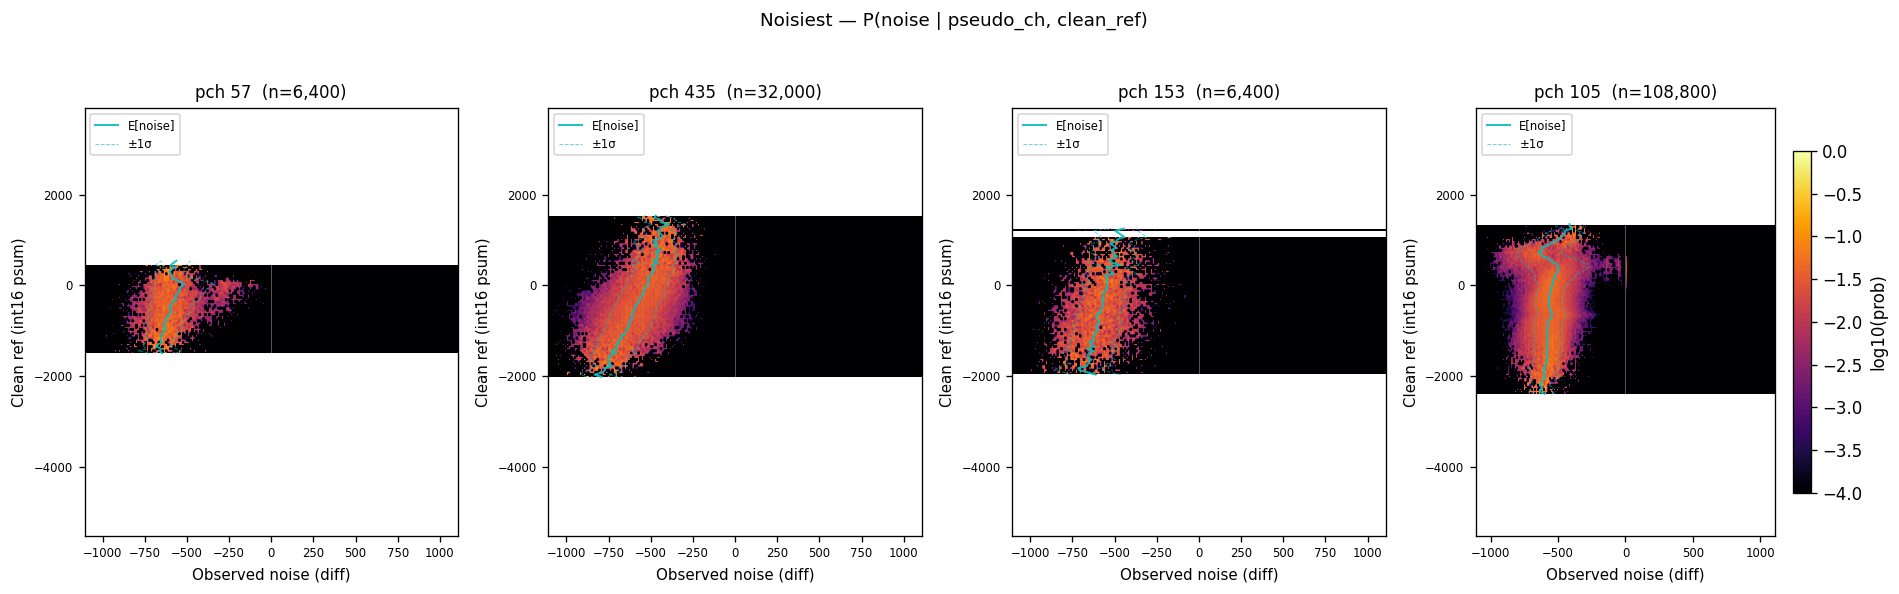

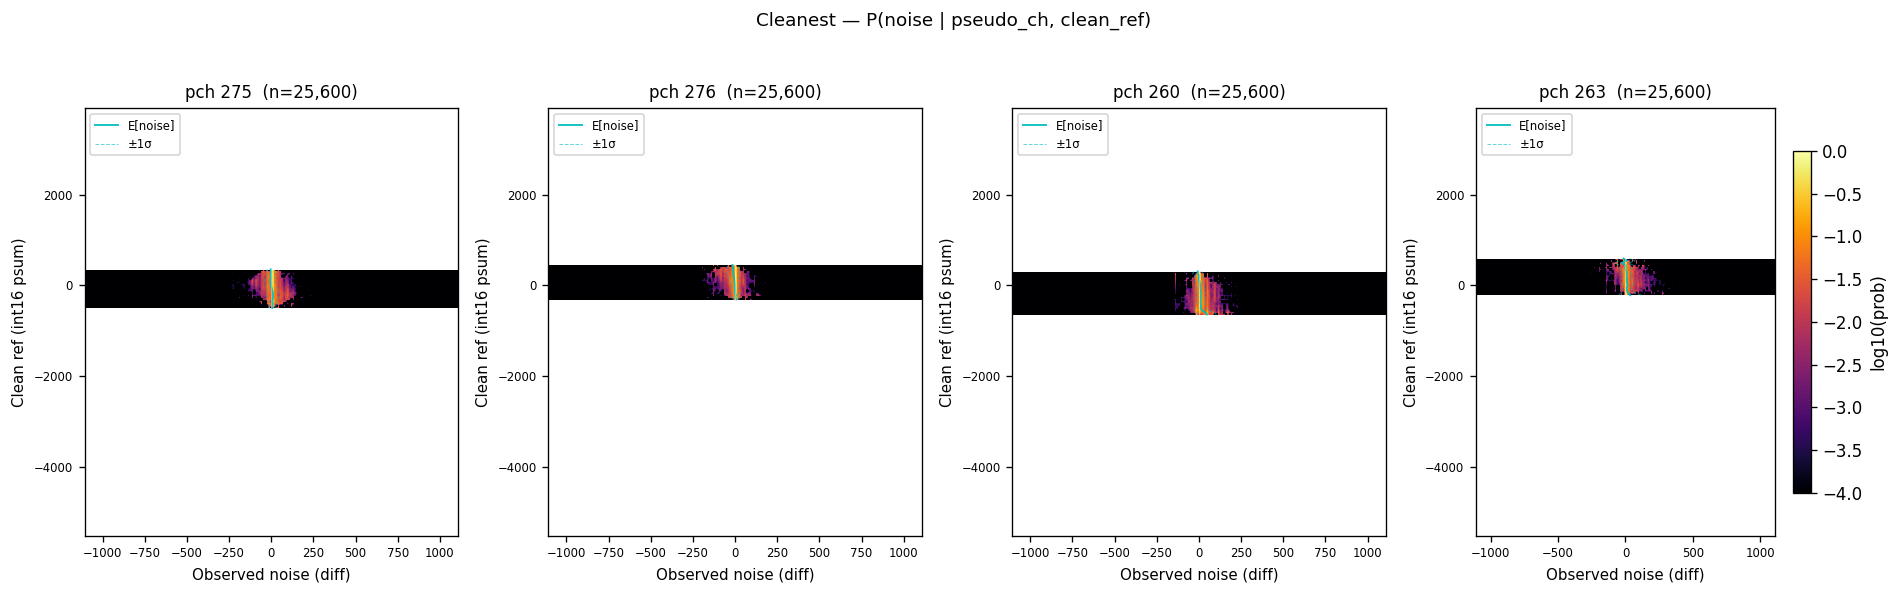

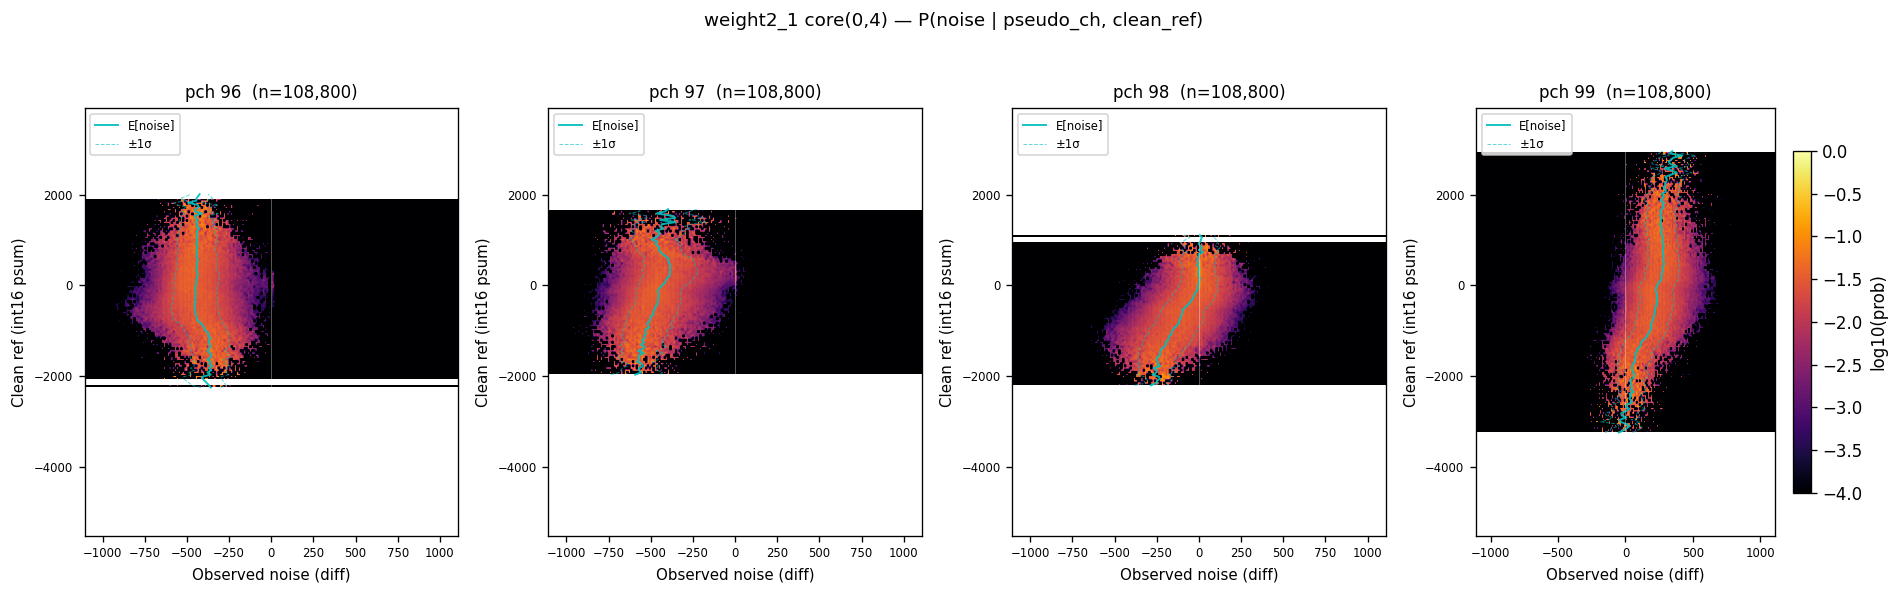

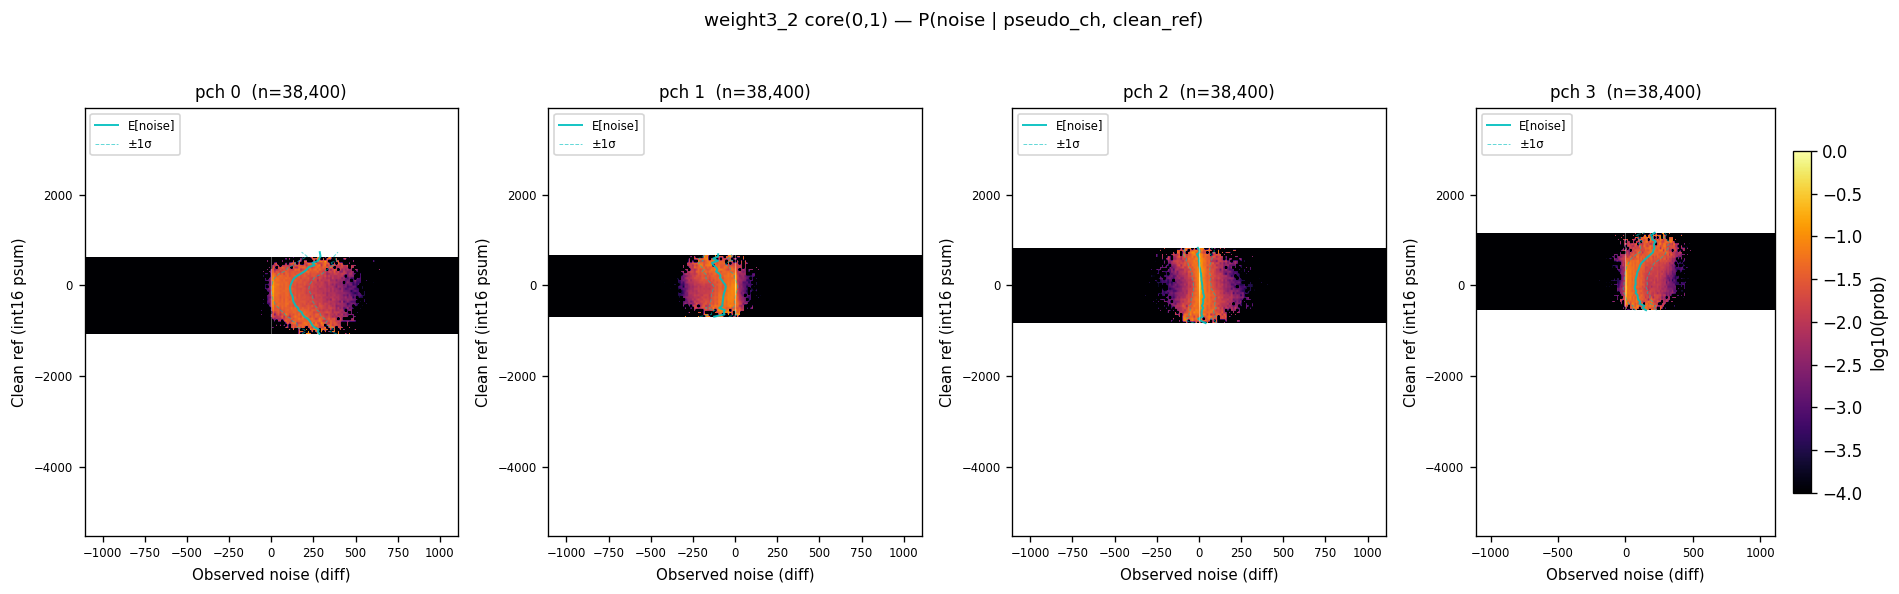

In [36]:
# Load aggregated noise table
NOISE_TABLE_PATH = os.path.join(
    CIM_DIR, 'noise/noise_df/B2_chip_inference/N32',
    CKPT_ALIAS, 'aggregated_noise_table.npz')
nt = np.load(NOISE_TABLE_PATH)
nt_probs = nt['probs']              # (n_pseudo, n_ref_bins, n_noise_bins)
nt_ref_centers = nt['ref_bin_centers']
nt_noise_centers = nt['noise_bin_centers']
nt_E = nt['E']
nt_Std = nt['Std']
nt_count = nt['count']
print(f"Noise table: {nt_probs.shape}")
print(f"  Ref range: [{nt_ref_centers[0]:.0f}, {nt_ref_centers[-1]:.0f}]")
print(f"  Noise range: [{nt_noise_centers[0]:.0f}, {nt_noise_centers[-1]:.0f}]")


def plot_noise_table_heatmap(pseudo_chs, title_prefix='', figsize=(16, 5)):
    """Heatmap per pseudo_ch: x=noise (diff), y=clean_ref, color=P(noise|ref).

    Also shows E[noise] and ±1σ overlay.
    """
    n = len(pseudo_chs)
    fig, axes = plt.subplots(1, n, figsize=(figsize[0], figsize[1]),
                             squeeze=False)

    for col, pch in enumerate(pseudo_chs):
        ax = axes[0, col]
        p = nt_probs[pch]        # (n_ref_bins, n_noise_bins)
        cnt = nt_count[pch]      # (n_ref_bins,)
        e = nt_E[pch]
        s = nt_Std[pch]

        # Mask rows with no data
        valid_rows = cnt >= 10
        p_plot = p.copy()
        p_plot[~valid_rows] = np.nan

        # Log-scale for better visibility
        with np.errstate(divide='ignore', invalid='ignore'):
            p_log = np.log10(p_plot + 1e-8)
        p_log[~valid_rows] = np.nan

        im = ax.imshow(p_log, aspect='auto', origin='lower', cmap='inferno',
                       extent=[nt_noise_centers[0], nt_noise_centers[-1],
                               nt_ref_centers[0], nt_ref_centers[-1]],
                       vmin=-4, vmax=0)

        # Overlay E[noise] ± 1σ
        valid_idx = np.where(valid_rows)[0]
        if len(valid_idx) > 0:
            ref_vals = nt_ref_centers[valid_idx]
            e_vals = e[valid_idx]
            s_vals = s[valid_idx]
            ax.plot(e_vals, ref_vals, 'c-', linewidth=1.2, alpha=0.9, label='E[noise]')
            ax.plot(e_vals - s_vals, ref_vals, 'c--', linewidth=0.6, alpha=0.6)
            ax.plot(e_vals + s_vals, ref_vals, 'c--', linewidth=0.6, alpha=0.6,
                    label='±1σ')

        ax.axvline(0, color='white', linewidth=0.5, alpha=0.4)
        ax.set_xlabel('Observed noise (diff)', fontsize=9)
        ax.set_ylabel('Clean ref (int16 psum)', fontsize=9)
        n_obs = cnt.sum()
        ax.set_title(f'pch {pch}  (n={n_obs:,})', fontsize=10)
        ax.legend(fontsize=7, loc='upper left')
        ax.tick_params(labelsize=7)

    plt.colorbar(im, ax=axes[0, -1], shrink=0.8, label='log10(prob)')
    fig.suptitle(f'{title_prefix}P(noise | pseudo_ch, clean_ref)', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig


# --- Select pseudo channels to visualize ---
# Top by |E| magnitude (noisiest)
pch_E_mag = np.array([
    np.abs(nt_E[p][nt_count[p] >= 10]).mean() if (nt_count[p] >= 10).any() else 0
    for p in range(nt_probs.shape[0])
])
top_noisy = list(np.argsort(pch_E_mag)[-4:][::-1])

# Least noisy (with enough data)
pch_total_obs = nt_count.sum(axis=1)
has_data = pch_total_obs > 1000
pch_E_mag_filtered = pch_E_mag.copy()
pch_E_mag_filtered[~has_data] = 999999
top_clean = list(np.argsort(pch_E_mag_filtered)[:4])

print(f"Noisiest pseudo_chs: {top_noisy}")
print(f"Cleanest pseudo_chs: {top_clean}")

fig1 = plot_noise_table_heatmap(top_noisy, title_prefix='Noisiest — ')
plt.show()
fig2 = plot_noise_table_heatmap(top_clean, title_prefix='Cleanest — ')
plt.show()

# Also show specific channels from earlier analysis
for func_name, label in [('tvmgen_default_imcflow_main_0', 'weight2_1 core(0,4)'),
                          ('tvmgen_default_imcflow_main_12', 'weight3_2 core(0,1)')]:
    if func_name in stacked:
        pchs = stacked[func_name]['pseudo_chs']
        # Pick first 4 channels
        sel = list(pchs[:4])
        fig = plot_noise_table_heatmap(sel, title_prefix=f'{label} — ')
        plt.show()

### 6.6 Multi-run noise table comparison

Compare single-run (run_00, 100 samples) vs multi-run (run_00..run_09, 1000 samples) noise tables.
Side-by-side heatmaps for the same pseudo_ch channels.

In [ ]:
# Load multi-run noise table
NOISE_TABLE_MULTI_PATH = os.path.join(
    CIM_DIR, 'noise/noise_df/B2_chip_inference/N32',
    CKPT_ALIAS, 'aggregated_noise_table_multi.npz')
nt_m = np.load(NOISE_TABLE_MULTI_PATH)
nt_m_probs = nt_m['probs']
nt_m_ref_centers = nt_m['ref_bin_centers']
nt_m_noise_centers = nt_m['noise_bin_centers']
nt_m_E = nt_m['E']
nt_m_Std = nt_m['Std']
nt_m_count = nt_m['count']
print(f"Multi-run noise table: {nt_m_probs.shape}")
print(f"  Total observations: {nt_m_count.sum():,} (single: {nt_count.sum():,}, ratio: {nt_m_count.sum()/nt_count.sum():.1f}x)")
print(f"  Ref range: [{nt_m_ref_centers[0]:.0f}, {nt_m_ref_centers[-1]:.0f}]")
print(f"  Noise range: [{nt_m_noise_centers[0]:.0f}, {nt_m_noise_centers[-1]:.0f}]")


def plot_noise_table_comparison(pseudo_chs, title_prefix='', figsize=(16, 8)):
    """Side-by-side heatmaps: single-run (top) vs multi-run (bottom) for each pseudo_ch."""
    n = len(pseudo_chs)
    fig, axes = plt.subplots(2, n, figsize=(figsize[0], figsize[1]), squeeze=False)

    for row, (probs, ref_c, noise_c, E, Std, count, label) in enumerate([
        (nt_probs, nt_ref_centers, nt_noise_centers, nt_E, nt_Std, nt_count, 'Single run (run_00)'),
        (nt_m_probs, nt_m_ref_centers, nt_m_noise_centers, nt_m_E, nt_m_Std, nt_m_count, 'Multi run (run_00..09)'),
    ]):
        for col, pch in enumerate(pseudo_chs):
            ax = axes[row, col]
            p = probs[pch]
            cnt = count[pch]
            e = E[pch]
            s = Std[pch]

            valid_rows = cnt >= 10
            p_plot = p.copy()
            p_plot[~valid_rows] = np.nan

            with np.errstate(divide='ignore', invalid='ignore'):
                p_log = np.log10(p_plot + 1e-8)
            p_log[~valid_rows] = np.nan

            im = ax.imshow(p_log, aspect='auto', origin='lower', cmap='inferno',
                           extent=[noise_c[0], noise_c[-1], ref_c[0], ref_c[-1]],
                           vmin=-4, vmax=0)

            valid_idx = np.where(valid_rows)[0]
            if len(valid_idx) > 0:
                ref_vals = ref_c[valid_idx]
                e_vals = e[valid_idx]
                s_vals = s[valid_idx]
                ax.plot(e_vals, ref_vals, 'c-', linewidth=1.2, alpha=0.9, label='E[noise]')
                ax.plot(e_vals - s_vals, ref_vals, 'c--', linewidth=0.6, alpha=0.6)
                ax.plot(e_vals + s_vals, ref_vals, 'c--', linewidth=0.6, alpha=0.6, label='±1σ')

            ax.axvline(0, color='white', linewidth=0.5, alpha=0.4)
            if row == 1:
                ax.set_xlabel('Observed noise (diff)', fontsize=9)
            if col == 0:
                ax.set_ylabel(f'{label}\nClean ref (int16 psum)', fontsize=9)
            n_obs = cnt.sum()
            ax.set_title(f'pch {pch}  (n={n_obs:,})', fontsize=10)
            ax.legend(fontsize=6, loc='upper left')
            ax.tick_params(labelsize=7)

    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.90, 0.10, 0.015, 0.78])
    fig.colorbar(im, cax=cbar_ax, label='log10(prob)')
    fig.suptitle(f'{title_prefix}P(noise | pseudo_ch, clean_ref)  —  single vs multi-run', fontsize=12)
    fig.tight_layout(rect=[0, 0, 0.88, 0.95])
    return fig


# --- Same channels as 6.5 ---
fig1 = plot_noise_table_comparison(top_noisy, title_prefix='Noisiest — ')
plt.show()
fig2 = plot_noise_table_comparison(top_clean, title_prefix='Cleanest — ')
plt.show()

# --- Per-pseudo_ch: E[noise] and Std comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Compare E[noise] per pseudo_ch (averaged over ref bins with enough data)
pch_E_single = np.array([
    np.abs(nt_E[p][nt_count[p] >= 10]).mean() if (nt_count[p] >= 10).any() else 0
    for p in range(nt_probs.shape[0])
])
pch_E_multi = np.array([
    np.abs(nt_m_E[p][nt_m_count[p] >= 10]).mean() if (nt_m_count[p] >= 10).any() else 0
    for p in range(nt_m_probs.shape[0])
])
pch_Std_single = np.array([
    nt_Std[p][nt_count[p] >= 10].mean() if (nt_count[p] >= 10).any() else 0
    for p in range(nt_probs.shape[0])
])
pch_Std_multi = np.array([
    nt_m_Std[p][nt_m_count[p] >= 10].mean() if (nt_m_count[p] >= 10).any() else 0
    for p in range(nt_m_probs.shape[0])
])

ax = axes[0]
ax.scatter(pch_E_single, pch_E_multi, s=8, alpha=0.6)
lim = max(pch_E_single.max(), pch_E_multi.max()) * 1.1
ax.plot([0, lim], [0, lim], 'r--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Single run |E[noise]|', fontsize=10)
ax.set_ylabel('Multi run |E[noise]|', fontsize=10)
ax.set_title('Mean |E[noise]| per pseudo_ch', fontsize=11)
ax.set_aspect('equal')

ax = axes[1]
ax.scatter(pch_Std_single, pch_Std_multi, s=8, alpha=0.6)
lim = max(pch_Std_single.max(), pch_Std_multi.max()) * 1.1
ax.plot([0, lim], [0, lim], 'r--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Single run Std[noise]', fontsize=10)
ax.set_ylabel('Multi run Std[noise]', fontsize=10)
ax.set_title('Mean Std[noise] per pseudo_ch', fontsize=11)
ax.set_aspect('equal')

fig.suptitle('Per-pseudo_ch noise stats: single vs multi-run', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"\nCorrelation |E|: {np.corrcoef(pch_E_single, pch_E_multi)[0,1]:.4f}")
print(f"Correlation Std: {np.corrcoef(pch_Std_single, pch_Std_multi)[0,1]:.4f}")

## 6. Per-sample spatial noise map (OH x OW)

Pick a specific atomic and visualize how noise is distributed spatially across samples.

In [ ]:
def plot_spatial_noise_maps(func, stacked, sample_indices=None, oc_idx=0, figsize=(18, 10)):
    """Show spatial (OH, OW) maps of observed noise, pred_E, and diff for selected samples."""
    s = stacked[func]
    n_samples = s['obs'].shape[0]
    if sample_indices is None:
        sample_indices = list(range(min(6, n_samples)))

    n = len(sample_indices)
    fig, axes = plt.subplots(3, n, figsize=figsize, squeeze=False)

    vmax_obs = np.percentile(np.abs(s['obs'][:, oc_idx]), 98)
    vmax_pred = np.percentile(np.abs(s['pred_E'][:, oc_idx]), 98)
    diff_all = s['obs'][:, oc_idx] - s['pred_E'][:, oc_idx]
    vmax_diff = np.percentile(np.abs(diff_all), 98)

    for col, si in enumerate(sample_indices):
        obs_map = s['obs'][si, oc_idx]     # (OH, OW)
        pred_map = s['pred_E'][si, oc_idx]
        diff_map = obs_map - pred_map

        im0 = axes[0, col].imshow(obs_map, cmap='RdBu_r', vmin=-vmax_obs, vmax=vmax_obs)
        axes[0, col].set_title(f's{si} observed', fontsize=8)

        im1 = axes[1, col].imshow(pred_map, cmap='RdBu_r', vmin=-vmax_pred, vmax=vmax_pred)
        axes[1, col].set_title(f's{si} pred_E', fontsize=8)

        im2 = axes[2, col].imshow(diff_map, cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff)
        axes[2, col].set_title(f's{si} obs-pred', fontsize=8)

        for row in range(3):
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])

    fig.colorbar(im0, ax=axes[0, :].tolist(), shrink=0.6, label='int16')
    fig.colorbar(im1, ax=axes[1, :].tolist(), shrink=0.6, label='int16')
    fig.colorbar(im2, ax=axes[2, :].tolist(), shrink=0.6, label='int16')
    fig.suptitle(f'{func} [{s["orig_conv"]}] oc={oc_idx} (pch={s["pseudo_chs"][oc_idx]})', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig, axes

# Plot for the worst-performing atomic (highest |z|>3%)
worst = max(rows_summary, key=lambda r: r['|z|>3%'])
print(f"Worst atomic: {worst['func']} ({worst['orig']}) |z|>3% = {worst['|z|>3%']:.1f}%")
plot_spatial_noise_maps(worst['func'], stacked, sample_indices=[0, 1, 2, 3, 4, 5])
plt.show()

## 7. Observed - Predicted diff heatmap (OC x flattened spatial)

Per-atomic: average across samples the (obs - pred_E) and show as (OC, OH*OW).

In [ ]:
def plot_obs_pred_diff_heatmap(func, stacked, figsize=(14, 5)):
    s = stacked[func]
    diff = s['obs'] - s['pred_E']   # (S, OC, OH, OW)
    # Mean across samples
    diff_mean = diff.mean(axis=0)   # (OC, OH, OW)
    OC, OH, OW = diff_mean.shape
    mat = diff_mean.reshape(OC, OH * OW)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Mean bias
    vmax = np.percentile(np.abs(mat), 98)
    im0 = axes[0].imshow(mat, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                         interpolation='nearest')
    axes[0].set_xlabel('Spatial position (OH*OW)')
    axes[0].set_ylabel('Output channel')
    axes[0].set_title('Mean(obs - pred_E) across samples')
    fig.colorbar(im0, ax=axes[0], shrink=0.7)

    # Std across samples
    diff_std = diff.std(axis=0).reshape(OC, OH * OW)
    im1 = axes[1].imshow(diff_std, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    axes[1].set_xlabel('Spatial position (OH*OW)')
    axes[1].set_ylabel('Output channel')
    axes[1].set_title('Std(obs - pred_E) across samples')
    fig.colorbar(im1, ax=axes[1], shrink=0.7)

    fig.suptitle(f'{func} [{s["orig_conv"]}] core{s["core"]}', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    return fig, axes

# Plot for all atomics
for f in atomic_funcs:
    plot_obs_pred_diff_heatmap(f, stacked)
    plt.show()

## 8. Channel-wise bias and std line plots

Per output channel: mean and std of observed noise across all samples & spatial positions.

In [ ]:
# Group by orig_conv
orig_groups = defaultdict(list)
for a in atomics:
    if a['func'] in stacked:
        orig_groups[a['orig_conv']].append(a)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for orig in sorted(orig_groups.keys()):
    group = orig_groups[orig]
    ch_means = []
    ch_stds = []
    ch_labels = []
    for a in group:
        s = stacked[a['func']]
        obs = s['obs']  # (S, OC, OH, OW)
        for oc in range(obs.shape[1]):
            vals = obs[:, oc, :, :].ravel()
            ch_means.append(vals.mean())
            ch_stds.append(vals.std())
            ch_labels.append(s['pseudo_chs'][oc])
    # Sort by pseudo_ch
    order = np.argsort(ch_labels)
    ch_means = np.array(ch_means)[order]
    ch_stds = np.array(ch_stds)[order]
    ch_labels_sorted = np.array(ch_labels)[order]

    axes[0].plot(range(len(ch_means)), ch_means, marker='.', markersize=3,
                 label=orig, linewidth=0.8)
    axes[1].plot(range(len(ch_stds)), ch_stds, marker='.', markersize=3,
                 label=orig, linewidth=0.8)

axes[0].set_ylabel('Mean observed noise')
axes[0].set_title('Per-channel mean(observed noise)')
axes[0].legend(fontsize=7, ncol=4)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[0].grid(alpha=0.3)

axes[1].set_ylabel('Std observed noise')
axes[1].set_xlabel('Channel index (sorted by pseudo_ch)')
axes[1].set_title('Per-channel std(observed noise)')
axes[1].legend(fontsize=7, ncol=4)
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 9. Per-channel observed vs predicted comparison

Scatter: per-channel mean(obs) vs mean(pred_E), and std(obs) vs sqrt(pred_Var).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for orig in sorted(orig_groups.keys()):
    obs_means = []; pred_means = []
    obs_stds = []; pred_stds = []
    for a in orig_groups[orig]:
        s = stacked[a['func']]
        for oc in range(s['obs'].shape[1]):
            obs_vals = s['obs'][:, oc, :, :].ravel()
            pred_e_vals = s['pred_E'][:, oc, :, :].ravel()
            pred_var_vals = s['pred_Var'][:, oc, :, :].ravel()
            obs_means.append(obs_vals.mean())
            pred_means.append(pred_e_vals.mean())
            obs_stds.append(obs_vals.std())
            pred_stds.append(np.sqrt(pred_var_vals).mean())

    axes[0].scatter(pred_means, obs_means, s=12, alpha=0.7, label=orig)
    axes[1].scatter(pred_stds, obs_stds, s=12, alpha=0.7, label=orig)

# Diagonal reference
for ax in axes:
    lim = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
           max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lim, lim, 'k--', linewidth=0.8, alpha=0.5)
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

axes[0].set_xlabel('Predicted E[noise] (per-channel mean)')
axes[0].set_ylabel('Observed noise (per-channel mean)')
axes[0].set_title('Mean: Observed vs Predicted')

axes[1].set_xlabel('Predicted std (sqrt(Var), per-channel mean)')
axes[1].set_ylabel('Observed std (per-channel)')
axes[1].set_title('Std: Observed vs Predicted')

fig.tight_layout()
plt.show()

## 10. Skip vs non-skip region analysis

Show how noise differs between spatially-skipped (popcount<8) and non-skipped regions.

In [ ]:
rows_skip = []
for a in atomics:
    if a['func'] not in stacked:
        continue
    s = stacked[a['func']]
    obs = s['obs']             # (S, OC, OH, OW)
    skip = s['skip_mask']      # (S, ABITS, OH, OW)
    # Any abit skipped at (s, oh, ow)
    skip_any = skip.any(axis=1)  # (S, OH, OW)
    # Broadcast to (S, OC, OH, OW)
    skip_broad = np.broadcast_to(skip_any[:, None, :, :], obs.shape)

    obs_skip = obs[skip_broad]
    obs_noskip = obs[~skip_broad]
    skip_frac = skip_broad.mean() * 100

    rows_skip.append({
        'func': a['func'],
        'orig': a['orig_conv'],
        'skip%': skip_frac,
        'skip_mean': obs_skip.mean() if obs_skip.size > 0 else np.nan,
        'skip_std': obs_skip.std() if obs_skip.size > 0 else np.nan,
        'noskip_mean': obs_noskip.mean() if obs_noskip.size > 0 else np.nan,
        'noskip_std': obs_noskip.std() if obs_noskip.size > 0 else np.nan,
    })

df_skip = pd.DataFrame(rows_skip)
df_skip.style.format({
    'skip%': '{:.1f}', 'skip_mean': '{:.1f}', 'skip_std': '{:.1f}',
    'noskip_mean': '{:.1f}', 'noskip_std': '{:.1f}',
})

In [ ]:
# Visual: skip mask overlay on spatial noise for worst atomic
def plot_skip_overlay(func, stacked, sample_idx=0, oc_idx=0, figsize=(12, 4)):
    s = stacked[func]
    obs_map = s['obs'][sample_idx, oc_idx]        # (OH, OW)
    skip_any = s['skip_mask'][sample_idx].any(axis=0)  # (OH, OW)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    vmax = np.percentile(np.abs(obs_map), 98)
    axes[0].imshow(obs_map, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[0].set_title('Observed noise')

    axes[1].imshow(skip_any, cmap='Greys', vmin=0, vmax=1)
    axes[1].set_title('Skip mask (any abit)')

    # Overlay: skip region with hatching
    axes[2].imshow(obs_map, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    skip_rgba = np.zeros((*skip_any.shape, 4))
    skip_rgba[skip_any, :] = [0, 0, 0, 0.25]  # semi-transparent black
    axes[2].imshow(skip_rgba)
    axes[2].set_title('Noise + skip overlay')

    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle(f'{func} [{s["orig_conv"]}] s={sample_idx} oc={oc_idx}', fontsize=10)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    return fig, axes

# Show for atomics that have significant skip%
skip_atomics = [r for r in rows_skip if r['skip%'] > 5]
skip_atomics.sort(key=lambda r: -r['skip%'])
for r in skip_atomics[:4]:
    plot_skip_overlay(r['func'], stacked)
    plt.show()

## 11. Ref vs Chip: raw psum comparison

Scatter plot of clean_ref vs chip_dump for a few samples. Perfect match = diagonal.

In [ ]:
def plot_ref_vs_chip_scatter(func, stacked, n_samples_plot=5, figsize=(14, 4)):
    s = stacked[func]
    n = min(n_samples_plot, s['obs'].shape[0])
    fig, axes = plt.subplots(1, n, figsize=figsize, squeeze=False)

    for col in range(n):
        ref = s['clean_ref'][col].ravel().astype(np.float32)
        chip = s['chip_dump'][col].ravel().astype(np.float32)
        ax = axes[0, col]
        ax.scatter(ref, chip, s=0.3, alpha=0.15, rasterized=True)
        lim = [min(ref.min(), chip.min()), max(ref.max(), chip.max())]
        ax.plot(lim, lim, 'r-', linewidth=0.7, alpha=0.7)
        ax.set_title(f'sample {col}', fontsize=9)
        ax.set_xlabel('psum_ref', fontsize=8)
        if col == 0:
            ax.set_ylabel('chip_dump', fontsize=8)
        ax.tick_params(labelsize=7)

    fig.suptitle(f'{func} [{s["orig_conv"]}] psum_ref vs chip_dump', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    return fig, axes

# Plot for worst and best atomics
best = min(rows_summary, key=lambda r: r['|z|>3%'])
for r in [worst, best]:
    print(f"{r['func']} ({r['orig']}) |z|>3% = {r['|z|>3%']:.1f}%")
    plot_ref_vs_chip_scatter(r['func'], stacked)
    plt.show()

## 12. Noise histogram per orig_conv

Aggregate observed noise distribution grouped by original convolution layer.

In [ ]:
origs = sorted(orig_groups.keys())
n_orig = len(origs)
cols = 4
rows_g = int(np.ceil(n_orig / cols))
fig, axes = plt.subplots(rows_g, cols, figsize=(4 * cols, 3 * rows_g), squeeze=False)

for idx, orig in enumerate(origs):
    r, c = divmod(idx, cols)
    ax = axes[r, c]
    all_obs = []
    all_pred_E = []
    for a in orig_groups[orig]:
        s = stacked[a['func']]
        all_obs.append(s['obs'].ravel())
        all_pred_E.append(s['pred_E'].ravel())
    all_obs = np.concatenate(all_obs)
    all_pred_E = np.concatenate(all_pred_E)

    clip = np.percentile(np.abs(all_obs), 99)
    bins = np.linspace(-clip, clip, 150)
    ax.hist(all_obs, bins=bins, density=True, alpha=0.6, label='observed', color='steelblue')
    ax.hist(all_pred_E, bins=bins, density=True, alpha=0.5, label='pred_E', color='coral',
            histtype='step', linewidth=1.5)
    ax.set_title(f'{orig}  (n={all_obs.size:,})', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlim(-clip, clip)
    ax.tick_params(labelsize=7)

for idx in range(n_orig, rows_g * cols):
    r, c = divmod(idx, cols)
    axes[r, c].set_visible(False)

fig.suptitle('Per-layer observed noise vs predicted E[noise] distribution', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 13. In-range % across samples (temporal stability)

Check if noise characteristics are stable across samples or drift over time.

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

for orig in sorted(orig_groups.keys()):
    per_sample_inrange = []
    for si in range(N_SAMPLES):
        ir_vals = []
        for a in orig_groups[orig]:
            s = stacked[a['func']]
            if si < s['in_range'].shape[0]:
                ir_vals.append(s['in_range'][si].ravel())
        if ir_vals:
            combined = np.concatenate(ir_vals)
            per_sample_inrange.append(combined.mean() * 100)
    ax.plot(per_sample_inrange, label=orig, linewidth=0.8, alpha=0.8)

ax.set_xlabel('Sample index')
ax.set_ylabel('In-range %')
ax.set_title('Per-sample in-range% by layer (temporal stability)')
ax.legend(fontsize=7, ncol=4)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()